# Agent-Based Market Simulator

A simple agent-based market simulator where heterogeneous agents interact through a
shared liquidity pool to produce emergent price, volume, and liquidity dynamics.

## Framework

**MDP (Markov Decision Process)**
- **State**: (position, unrealized_pnl_pct, size, portfolio_value, price_return_1bar)
  - All state variables are current-bar values, computed by the engine before the agent acts.
  - `unrealized_pnl_pct` is updated by the engine each bar from its internal bookkeeping
    (entry_price). The agent never sees or stores entry_price -- only the resulting P&L percentage.
- **Action**: {LONG, SHORT, FLAT} (desired position, not a trade -- the engine computes the required trade)
- **Transition**: Deterministic given state. Agents have fixed policies (bias + risk tolerance).
- **Reward**: Change in portfolio value (realized + unrealized).
- **Markov property**: No history. Policy depends only on current state.

**Observation**: Fully deterministic. The engine computes all state variables and writes
them to the agent before the agent's policy runs. No stochasticity in observation.

**Action selection**: Epsilon-greedy. All agents deterministically compute their preferred
action from their policy, then with probability epsilon (default 2%) take a uniformly
random action instead. This is the only source of agent-level stochasticity, applied
uniformly to all agent types.

**Environmental stochasticity**: The noise term in the price formation model (Gaussian,
calibrated to asset-specific hourly volatility) is the primary source of randomness.

**Price Formation (Square-Root Impact Model)**

Based on Kyle (1985) and Almgren-Chriss (2000). The empirically observed relationship
between order flow and price impact follows a concave (square-root) function:

```
delta_price = drift + sigma * sign(Q) * sqrt(|Q| / L) + noise
```

Where:
- `drift` = exogenous market condition (bullish/bearish/neutral), expressed as expected hourly return
- `sigma` = asset volatility (scales how much a unit of imbalance moves price)
- `Q` = net order flow = sum(buy_volume) - sum(sell_volume) across all agents
- `L` = current liquidity depth (a pool that is consumed by trades and replenishes over time)
- `noise` = Gaussian random component calibrated to asset-specific hourly volatility

**Why square root?** Doubling order size does not double price impact. The first units
of an order execute against the densest liquidity near the midpoint. Subsequent units
hit progressively thinner levels. Empirical studies across equities, futures, and crypto
consistently find impact ~ sqrt(volume). This is the standard model in execution cost
analysis and the foundation of optimal execution algorithms (VWAP, TWAP, etc.).

**Volume and Liquidity**
- Volume is an INPUT: agents generate orders, orders aggregate into volume.
- Price change is an OUTPUT: volume hitting the liquidity pool produces price movement.
- Liquidity is consumed by trades and mean-reverts toward a baseline over time.
- When liquidity is thin, the same order flow produces larger price moves (higher impact).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from enum import Enum
from typing import List, Dict, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Asset Configuration

Each asset has different volatility, liquidity characteristics, and starting price.
Parameters are calibrated to approximate real-world hourly behavior.

In [2]:
class MarketCondition(Enum):
    BULLISH = "bullish"
    BEARISH = "bearish"
    NEUTRAL = "neutral"


@dataclass
class AssetConfig:
    name: str
    symbol: str
    initial_price: float

    # -- Volatility --
    # Hourly volatility (std dev of hourly returns).
    # Approximate: daily_vol / sqrt(24) for 24/7 assets.
    # BTC daily vol ~ 3-4%, hourly ~ 0.6-0.8%
    # Gold daily vol ~ 0.8-1.0%, hourly ~ 0.16-0.20%
    # META daily vol ~ 2-3%, hourly ~ 0.4-0.6% (using 24h for simplicity)
    # Crude daily vol ~ 1.5-2.5%, hourly ~ 0.3-0.5%
    hourly_volatility: float

    # -- Liquidity --
    # Base liquidity depth (abstract units). Higher = harder to move price.
    # Think of it as "how many units of net flow to move price by 1 sigma".
    base_liquidity: float
    
    # How fast liquidity replenishes toward base (0-1, per bar).
    # Higher = more resilient market (market makers re-enter quickly).
    # This is where black swans can be modelled. 
    liquidity_recovery_rate: float

    # -- Impact scaling --
    # Multiplier on the sqrt-impact term. Calibrate so that typical agent flow
    # produces reasonable price moves relative to the noise term.
    impact_coefficient: float

    # -- Drift per market condition (hourly expected return) --
    # Bullish: positive drift, Bearish: negative, Neutral: ~zero
    drift_bullish: float = 0.0
    drift_bearish: float = 0.0
    drift_neutral: float = 0.0

    def get_drift(self, condition: MarketCondition) -> float:
        if condition == MarketCondition.BULLISH:
            return self.drift_bullish
        elif condition == MarketCondition.BEARISH:
            return self.drift_bearish
        return self.drift_neutral


ASSETS = {
    "BTC": AssetConfig(
        name="Bitcoin", symbol="BTC",
        initial_price=67000.0,
        hourly_volatility=0.007,
        base_liquidity=500.0,
        liquidity_recovery_rate=0.15,
        impact_coefficient=0.4,
        drift_bullish=0.00035,     # ~0.035%/hr -> ~60% over 60d compounded
        drift_bearish=-0.00030,
        drift_neutral=0.00002,
    ),
    "XAU": AssetConfig(
        name="Gold", symbol="XAU",
        initial_price=2350.0,
        hourly_volatility=0.0018,
        base_liquidity=800.0,
        liquidity_recovery_rate=0.25,
        impact_coefficient=0.25,
        drift_bullish=0.00010,
        drift_bearish=-0.00008,
        drift_neutral=0.00001,
    ),
    "META": AssetConfig(
        name="Meta Platforms", symbol="META",
        initial_price=500.0,
        hourly_volatility=0.005,
        base_liquidity=600.0,
        liquidity_recovery_rate=0.20,
        impact_coefficient=0.35,
        drift_bullish=0.00025,
        drift_bearish=-0.00022,
        drift_neutral=0.00003,
    ),
    "CL": AssetConfig(
        name="Crude Oil", symbol="CL",
        initial_price=78.0,
        hourly_volatility=0.003,
        base_liquidity=700.0,
        liquidity_recovery_rate=0.20,
        impact_coefficient=0.30,
        drift_bullish=0.00018,
        drift_bearish=-0.00015,
        drift_neutral=0.00000,
    ),
}

for k, a in ASSETS.items():
    daily_vol_approx = a.hourly_volatility * np.sqrt(24) * 100
    print(f"{a.symbol:>5} | price: ${a.initial_price:>10,.2f} | hourly vol: {a.hourly_volatility*100:.2f}% | ~daily vol: {daily_vol_approx:.1f}%")

  BTC | price: $ 67,000.00 | hourly vol: 0.70% | ~daily vol: 3.4%
  XAU | price: $  2,350.00 | hourly vol: 0.18% | ~daily vol: 0.9%
 META | price: $    500.00 | hourly vol: 0.50% | ~daily vol: 2.4%
   CL | price: $     78.00 | hourly vol: 0.30% | ~daily vol: 1.5%


## 2. Agent (MDP Policy)

Each agent has:
- A **bias** that determines how they interpret market conditions (deterministic signal weights)
- A **risk tolerance** that determines position sizing and stop/take-profit levels
- A deterministic **policy** that maps current state -> preferred action
- **Epsilon-greedy action selection**: with probability epsilon (default 2%), the agent
  takes a uniformly random action instead of its policy action. This is the ONLY source
  of agent-level stochasticity, applied uniformly to all agent types.
- Its own RNG seeded uniquely per agent (used solely for epsilon-greedy coin flip)

**State/action boundary**: The agent's observable state is
`(position, unrealized_pnl_pct, size, portfolio_value, price_return_1bar)`.
All values are current-bar, computed by the engine. The agent does not store
`entry_price` -- that is engine bookkeeping used to compute `unrealized_pnl_pct`.

**Signal computation is fully deterministic.** Given the same inputs (price return,
market condition), the same agent bias always produces the same signal. There are no
random draws in observation processing.

**Agent biases:**
- **Trend follower** (30%): aligns with drift direction and recent return
- **Mean reverter** (15%): fades moves, bets on pullbacks
- **Momentum** (25%): enters on strong moves, pure return-chaser
- **Contrarian** (15%): opposes prevailing condition and return
- **Passive** (15%): weak directional lean from condition only, low conviction

No history, no lookback.

In [ ]:
class Position(Enum):
    LONG = 1
    FLAT = 0
    SHORT = -1

# All possible actions for epsilon-greedy random selection
ALL_POSITIONS = [Position.LONG, Position.FLAT, Position.SHORT]


class AgentBias(Enum):
    TREND_FOLLOWER = "trend_follower"       # aligns with drift direction
    MEAN_REVERTER = "mean_reverter"          # fades moves, bets on pullbacks
    MOMENTUM = "momentum"                    # enters on strong moves, pure return-chaser
    CONTRARIAN = "contrarian"                # opposes the prevailing condition
    PASSIVE = "passive"                      # weak directional lean, low conviction


@dataclass
class AgentState:
    """Observable state passed to the agent's policy. All values are current-bar."""
    position: Position = Position.FLAT
    unrealized_pnl_pct: float = 0.0   # computed by engine each bar
    size: float = 0.0                  # units held (positive=long, negative=short)
    cash: float = 10000.0
    realized_pnl: float = 0.0


@dataclass
class Agent:
    agent_id: int
    bias: AgentBias
    risk_tolerance: float           # 0.0 (conservative) to 1.0 (aggressive)
    # MDP policy parameters (deterministic thresholds)
    entry_threshold: float          # how much signal needed to enter
    stop_loss_pct: float            # close position if unrealized loss exceeds this
    take_profit_pct: float          # close position if unrealized gain exceeds this
    max_position_pct: float         # max fraction of capital to risk
    # Epsilon-greedy parameter: probability of taking a random action
    epsilon: float = 0.02
    # Per-agent RNG (used ONLY for epsilon-greedy coin flip, never for signal computation)
    rng: np.random.Generator = field(default_factory=lambda: np.random.default_rng())
    # State
    state: AgentState = field(default_factory=AgentState)

    def get_desired_action(
        self,
        current_price: float,
        price_return_1bar: float,
        market_condition: MarketCondition,
    ) -> Tuple[Position, float]:
        """
        MDP policy with epsilon-greedy action selection.

        1. Deterministically compute signal and preferred action from policy
        2. With probability epsilon, override with a uniformly random action
        3. Return (desired_position, desired_size)

        The engine computes the trade needed to reach the desired position.
        """
        # -- Risk management: stop loss and take profit (overrides all else) --
        # These are deterministic and NOT subject to epsilon-greedy override.
        # Risk management is a hard constraint, not a policy choice.
        if self.state.position != Position.FLAT:
            if self.state.unrealized_pnl_pct <= -self.stop_loss_pct:
                return Position.FLAT, 0.0
            if self.state.unrealized_pnl_pct >= self.take_profit_pct:
                return Position.FLAT, 0.0

        # -- Compute directional signal based on bias (fully deterministic) --
        signal = self._compute_signal(price_return_1bar, market_condition)

        # -- Map signal to preferred action (deterministic policy) --
        portfolio_value = self.state.cash + abs(self.state.size) * current_price
        max_notional = portfolio_value * self.max_position_pct
        desired_size = max_notional / current_price if current_price > 0 else 0.0

        if signal > self.entry_threshold:
            policy_action = Position.LONG
            policy_size = desired_size * min(abs(signal), 1.0)
        elif signal < -self.entry_threshold:
            policy_action = Position.SHORT
            policy_size = desired_size * min(abs(signal), 1.0)
        else:
            # Signal too weak -- hold current position or stay flat
            if self.state.position != Position.FLAT:
                policy_action = self.state.position
                policy_size = abs(self.state.size)
            else:
                policy_action = Position.FLAT
                policy_size = 0.0

        # -- Epsilon-greedy: with probability epsilon, take a random action --
        if self.rng.uniform() < self.epsilon:
            random_action = self.rng.choice(ALL_POSITIONS)
            if random_action == Position.FLAT:
                return Position.FLAT, 0.0
            else:
                # Use policy-computed size for the random action direction
                return random_action, desired_size * self.rng.uniform(0.3, 1.0)

        return policy_action, policy_size

    def _compute_signal(self, price_return_1bar: float, condition: MarketCondition) -> float:
        """
        Fully deterministic signal computation based on agent bias.
        Given the same inputs, the same bias always produces the same output.
        No random draws. Inputs are current-bar only (Markov property).
        """
        # Condition encoding: bullish=1, neutral=0, bearish=-1
        cond_val = {
            MarketCondition.BULLISH: 1.0,
            MarketCondition.NEUTRAL: 0.0,
            MarketCondition.BEARISH: -1.0,
        }[condition]

        # Normalize return to roughly -1 to 1 range
        # Divide by a typical hourly move (~0.5%) to normalize
        norm_return = np.clip(price_return_1bar / 0.005, -2.0, 2.0)

        if self.bias == AgentBias.TREND_FOLLOWER:
            # Aligns with both the macro condition and recent price movement
            return 0.6 * cond_val + 0.4 * norm_return

        elif self.bias == AgentBias.MEAN_REVERTER:
            # Weak agreement with macro condition, strong fade of recent move
            return 0.2 * cond_val - 0.8 * norm_return

        elif self.bias == AgentBias.MOMENTUM:
            # Pure price-chaser: only cares about recent return direction
            return norm_return

        elif self.bias == AgentBias.CONTRARIAN:
            # Opposes both the macro condition and recent move
            return -0.7 * cond_val - 0.3 * norm_return

        elif self.bias == AgentBias.PASSIVE:
            # Weak directional lean from condition only, ignores recent return.
            # Low conviction means these agents mostly stay flat or hold
            # unless the market condition is strong.
            return 0.3 * cond_val

        return 0.0


def create_agent_population(n_agents: int, rng: np.random.Generator) -> List[Agent]:
    """
    Create a heterogeneous population of agents.
    Distribution roughly models a real market:
    - 30% trend followers (institutional, systematic)
    - 15% mean reverters (market makers, stat arb)
    - 25% momentum (short-term traders)
    - 15% contrarian (value investors, macro)
    - 15% passive (retail, long-only, weak conviction)

    Each agent gets a unique RNG seeded from its agent_id + a base seed,
    so different simulations produce different agent behavior even with
    the same population structure. The RNG is used ONLY for epsilon-greedy
    action selection, never for signal computation.
    """
    base_seed = rng.integers(0, 2**31)

    bias_distribution = [
        (AgentBias.TREND_FOLLOWER, 0.30),
        (AgentBias.MEAN_REVERTER, 0.15),
        (AgentBias.MOMENTUM, 0.25),
        (AgentBias.CONTRARIAN, 0.15),
        (AgentBias.PASSIVE, 0.15),
    ]

    agents = []
    agent_id = 0
    for bias, pct in bias_distribution:
        count = int(n_agents * pct)
        for _ in range(count):
            agent_rng = np.random.default_rng(base_seed + agent_id)
            risk_tol = np.clip(agent_rng.beta(2, 3), 0.05, 0.95)

            # Passive agents get higher entry thresholds (harder to move them)
            if bias == AgentBias.PASSIVE:
                entry_thresh = agent_rng.uniform(0.4, 0.8)
            else:
                entry_thresh = agent_rng.uniform(0.15, 0.6)

            agents.append(Agent(
                agent_id=agent_id,
                bias=bias,
                risk_tolerance=risk_tol,
                entry_threshold=entry_thresh,
                stop_loss_pct=agent_rng.uniform(0.01, 0.05) * (1 + risk_tol),
                take_profit_pct=agent_rng.uniform(0.02, 0.10) * (1 + risk_tol),
                max_position_pct=agent_rng.uniform(0.1, 0.5) * risk_tol,
                epsilon=0.02,
                rng=agent_rng,
                state=AgentState(cash=agent_rng.uniform(5000, 50000)),
            ))
            agent_id += 1

    # Fill remaining to hit exact n_agents (rounding from percentages)
    while len(agents) < n_agents:
        agent_rng = np.random.default_rng(base_seed + agent_id)
        risk_tol = np.clip(agent_rng.beta(2, 3), 0.05, 0.95)
        agents.append(Agent(
            agent_id=agent_id,
            bias=rng.choice([b for b, _ in bias_distribution]),
            risk_tolerance=risk_tol,
            entry_threshold=agent_rng.uniform(0.15, 0.6),
            stop_loss_pct=agent_rng.uniform(0.01, 0.05) * (1 + risk_tol),
            take_profit_pct=agent_rng.uniform(0.02, 0.10) * (1 + risk_tol),
            max_position_pct=agent_rng.uniform(0.1, 0.5) * risk_tol,
            epsilon=0.02,
            rng=agent_rng,
            state=AgentState(cash=agent_rng.uniform(5000, 50000)),
        ))
        agent_id += 1

    return agents


print(f"Agent framework ready. Biases: {[b.value for b in AgentBias]}")
print(f"All signal computation: deterministic")
print(f"Action selection: epsilon-greedy (epsilon=0.02)")

## 3. Market Engine

The engine processes one timestep:
1. Each agent observes current state and declares desired position (MDP policy)
2. Engine computes the trade needed for each agent to reach desired position
3. Trades aggregate into net order flow (buy volume - sell volume)
4. Net flow hits the liquidity pool via the square-root impact model
5. Price updates, liquidity adjusts, volume is recorded

In [ ]:
@dataclass
class BarData:
    timestamp: int          # bar index
    open: float
    high: float
    low: float
    close: float
    volume: float           # total units traded
    buy_volume: float
    sell_volume: float
    net_flow: float         # buy_volume - sell_volume
    liquidity: float        # liquidity depth at bar close
    n_longs: int            # agents with long positions
    n_shorts: int
    n_flat: int
    n_trades: int           # number of agents that changed position


class MarketEngine:
    def __init__(self, asset: AssetConfig, condition: MarketCondition, seed: int = 42):
        self.asset = asset
        self.condition = condition
        self.rng = np.random.default_rng(seed)

        self.price = asset.initial_price
        self.liquidity = asset.base_liquidity
        self.history: List[BarData] = []
        self.trade_log: List[Dict] = []

        # Engine bookkeeping: entry prices per agent (agent_id -> entry_price).
        # This is NOT part of agent state. The engine uses it to compute
        # unrealized_pnl_pct, which it then writes to agent state as a
        # current-bar observable before the agent's policy runs.
        self._entry_prices: Dict[int, float] = {}

    def _update_agent_observations(self, agents: List[Agent]) -> None:
        """
        Pre-step: compute unrealized_pnl_pct for each agent and write it
        into their observable state. This is the engine providing current-bar
        state to the agent before the agent's policy executes.
        """
        for agent in agents:
            if agent.state.position == Position.FLAT:
                agent.state.unrealized_pnl_pct = 0.0
                continue

            entry_price = self._entry_prices.get(agent.agent_id, 0.0)
            if entry_price <= 0:
                agent.state.unrealized_pnl_pct = 0.0
                continue

            if agent.state.position == Position.LONG:
                agent.state.unrealized_pnl_pct = (self.price - entry_price) / entry_price
            else:  # SHORT
                agent.state.unrealized_pnl_pct = (entry_price - self.price) / entry_price

    def step(self, agents: List[Agent], bar_index: int) -> BarData:
        """
        Process one timestep (1 hour).

        Sequence:
        1. Engine computes unrealized_pnl_pct and writes to agent state (observation)
        2. Agents decide desired positions (policy reads current state)
        3. Compute trades needed to reach desired positions
        4. Aggregate net order flow
        5. Apply square-root impact model to get price change
        6. Update liquidity pool
        7. Settle agent positions at new price; update engine bookkeeping
        """
        bar_open = self.price

        # Compute the return of the PREVIOUS completed bar (open-to-close).
        # This is what agents observe as "what did the market just do?"
        # On bar 0 there is no previous bar, so the return is 0.
        last_return = 0.0
        if len(self.history) > 0:
            prev_bar = self.history[-1]
            if prev_bar.open > 0:
                last_return = (prev_bar.close - prev_bar.open) / prev_bar.open

        # -- Phase 0: Update agent observations --
        self._update_agent_observations(agents)

        # -- Phase 1: Collect agent decisions --
        total_buy_volume = 0.0
        total_sell_volume = 0.0
        trades_this_bar = 0

        agent_orders = []  # (agent, trade_size) where positive=buy, negative=sell

        for agent in agents:
            desired_pos, desired_size = agent.get_desired_action(
                self.price, last_return, self.condition
            )

            # Compute trade needed to reach desired position
            current_size = agent.state.size  # positive=long, negative=short
            if desired_pos == Position.LONG:
                target_size = abs(desired_size)
            elif desired_pos == Position.SHORT:
                target_size = -abs(desired_size)
            else:
                target_size = 0.0

            trade_size = target_size - current_size

            if abs(trade_size) > 1e-10:
                agent_orders.append((agent, trade_size))
                if trade_size > 0:
                    total_buy_volume += abs(trade_size)
                else:
                    total_sell_volume += abs(trade_size)
                trades_this_bar += 1

        # -- Phase 2: Price formation via square-root impact --
        net_flow = total_buy_volume - total_sell_volume
        total_volume = total_buy_volume + total_sell_volume

        drift = self.asset.get_drift(self.condition)
        noise = self.rng.normal(0, self.asset.hourly_volatility)

        # Square-root impact: delta = coeff * sign(Q) * sqrt(|Q| / L)
        if self.liquidity > 0 and abs(net_flow) > 1e-10:
            flow_ratio = abs(net_flow) / self.liquidity
            impact = self.asset.impact_coefficient * np.sign(net_flow) * np.sqrt(flow_ratio)
        else:
            impact = 0.0

        # Price change as a return
        price_return = drift + impact * self.asset.hourly_volatility + noise
        new_price = self.price * (1 + price_return)
        new_price = max(new_price, self.price * 0.9)  # circuit breaker: max 10% drop per bar
        new_price = min(new_price, self.price * 1.1)  # circuit breaker: max 10% rise per bar

        # Compute OHLC (simplified: use noise to create intra-bar range)
        intrabar_noise = abs(self.rng.normal(0, self.asset.hourly_volatility * 0.5))
        bar_high = max(bar_open, new_price) * (1 + intrabar_noise)
        bar_low = min(bar_open, new_price) * (1 - intrabar_noise)

        # -- Phase 3: Update liquidity --
        liquidity_consumed = total_volume * 0.1
        self.liquidity = max(self.liquidity - liquidity_consumed, self.asset.base_liquidity * 0.1)
        self.liquidity += (self.asset.base_liquidity - self.liquidity) * self.asset.liquidity_recovery_rate

        # -- Phase 4: Settle agent positions at new price --
        self.price = new_price

        for agent, trade_size in agent_orders:
            trade_value = trade_size * self.price
            entry_price = self._entry_prices.get(agent.agent_id, 0.0)

            # If closing (fully or partially), realize P&L
            if agent.state.position != Position.FLAT and entry_price > 0:
                closing_size = 0.0
                if trade_size < 0 and agent.state.size > 0:  # selling a long
                    closing_size = min(abs(trade_size), agent.state.size)
                elif trade_size > 0 and agent.state.size < 0:  # covering a short
                    closing_size = min(abs(trade_size), abs(agent.state.size))

                if closing_size > 0:
                    if agent.state.position == Position.LONG:
                        pnl = closing_size * (self.price - entry_price)
                    else:
                        pnl = closing_size * (entry_price - self.price)
                    agent.state.realized_pnl += pnl
                    agent.state.cash += pnl

            # Update agent position state
            agent.state.size += trade_size
            agent.state.cash -= trade_value

            # Update engine bookkeeping for entry_price
            if abs(agent.state.size) < 1e-10:
                agent.state.position = Position.FLAT
                agent.state.size = 0.0
                self._entry_prices.pop(agent.agent_id, None)
            elif agent.state.size > 0:
                agent.state.position = Position.LONG
                if agent.agent_id not in self._entry_prices:
                    self._entry_prices[agent.agent_id] = self.price
            else:
                agent.state.position = Position.SHORT
                if agent.agent_id not in self._entry_prices:
                    self._entry_prices[agent.agent_id] = self.price

            self.trade_log.append({
                "bar": bar_index,
                "agent_id": agent.agent_id,
                "bias": agent.bias.value,
                "trade_size": trade_size,
                "price": self.price,
                "new_position": agent.state.position.value,
            })

        # -- Count positions --
        n_longs = sum(1 for a in agents if a.state.position == Position.LONG)
        n_shorts = sum(1 for a in agents if a.state.position == Position.SHORT)
        n_flat = sum(1 for a in agents if a.state.position == Position.FLAT)

        bar = BarData(
            timestamp=bar_index,
            open=bar_open, high=bar_high, low=bar_low, close=self.price,
            volume=total_volume,
            buy_volume=total_buy_volume,
            sell_volume=total_sell_volume,
            net_flow=net_flow,
            liquidity=self.liquidity,
            n_longs=n_longs, n_shorts=n_shorts, n_flat=n_flat,
            n_trades=trades_this_bar,
        )
        self.history.append(bar)
        return bar


print("Market engine ready.")

## 4. Simulation Runner

In [ ]:
@dataclass
class SimulationResult:
    asset: AssetConfig
    condition: MarketCondition
    n_agents: int
    n_bars: int
    bars: List[BarData]
    trade_log: List[Dict]
    agents: List[Agent]
    # Engine bookkeeping snapshot for post-sim analysis
    entry_prices: Dict[int, float]  # agent_id -> entry_price (only agents still in positions)

    # Convenience arrays for plotting
    @property
    def closes(self) -> np.ndarray:
        return np.array([b.close for b in self.bars])

    @property
    def opens(self) -> np.ndarray:
        return np.array([b.open for b in self.bars])

    @property
    def highs(self) -> np.ndarray:
        return np.array([b.high for b in self.bars])

    @property
    def lows(self) -> np.ndarray:
        return np.array([b.low for b in self.bars])

    @property
    def volumes(self) -> np.ndarray:
        return np.array([b.volume for b in self.bars])

    @property
    def liquidities(self) -> np.ndarray:
        return np.array([b.liquidity for b in self.bars])

    @property
    def net_flows(self) -> np.ndarray:
        return np.array([b.net_flow for b in self.bars])

    @property
    def n_longs_arr(self) -> np.ndarray:
        return np.array([b.n_longs for b in self.bars])

    @property
    def n_shorts_arr(self) -> np.ndarray:
        return np.array([b.n_shorts for b in self.bars])

    def get_agent_pnl(self, agent: Agent) -> float:
        """Compute total P&L (realized + unrealized) for an agent."""
        unrealized = 0.0
        entry_price = self.entry_prices.get(agent.agent_id, 0.0)
        if agent.state.position == Position.LONG and entry_price > 0:
            unrealized = agent.state.size * (self.closes[-1] - entry_price)
        elif agent.state.position == Position.SHORT and entry_price > 0:
            unrealized = abs(agent.state.size) * (entry_price - self.closes[-1])
        return agent.state.realized_pnl + unrealized


def run_simulation(
    asset_key: str,
    condition: MarketCondition,
    n_agents: int = 500,
    n_days: int = 60,
    seed: int = 42,
) -> SimulationResult:
    asset = ASSETS[asset_key]
    n_bars = n_days * 24  # 24/7 market

    rng = np.random.default_rng(seed)
    agents = create_agent_population(n_agents, rng)
    engine = MarketEngine(asset, condition, seed=seed)

    for i in range(n_bars):
        engine.step(agents, i)

    return SimulationResult(
        asset=asset,
        condition=condition,
        n_agents=n_agents,
        n_bars=n_bars,
        bars=engine.history,
        trade_log=engine.trade_log,
        agents=agents,
        entry_prices=dict(engine._entry_prices),
    )


print("Simulation runner ready.")

## 5. Visualization

In [ ]:
def plot_simulation(result: SimulationResult):
    fig, axes = plt.subplots(5, 1, figsize=(18, 20), sharex=True,
                             gridspec_kw={'height_ratios': [3, 1.2, 1.2, 1.2, 1]})

    title = f"{result.asset.name} ({result.asset.symbol}) | {result.condition.value.upper()} | {result.n_agents} agents | {result.n_bars} bars ({result.n_bars // 24}d)"
    fig.suptitle(title, fontsize=14, fontweight='bold')

    x = np.arange(result.n_bars)
    day_ticks = np.arange(0, result.n_bars, 24 * 5)  # every 5 days
    day_labels = [f"D{i // 24}" for i in day_ticks]

    # -- Panel 1: Price (OHLC as filled range) --
    ax = axes[0]
    ax.fill_between(x, result.lows, result.highs, alpha=0.15, color='steelblue')
    ax.plot(x, result.closes, linewidth=0.8, color='steelblue', label='Close')
    ax.set_ylabel(f'Price ({result.asset.symbol})', fontweight='bold')
    start_p = result.opens[0]
    end_p = result.closes[-1]
    ret = (end_p - start_p) / start_p * 100
    ax.set_title(f"${start_p:,.2f} -> ${end_p:,.2f} ({ret:+.1f}%)", fontsize=10, loc='left')
    ax.legend(loc='upper left')

    # -- Panel 2: Volume (buy vs sell) --
    ax = axes[1]
    buy_vols = np.array([b.buy_volume for b in result.bars])
    sell_vols = np.array([b.sell_volume for b in result.bars])
    ax.bar(x, buy_vols, width=1.0, color='green', alpha=0.5, label='Buy volume')
    ax.bar(x, -sell_vols, width=1.0, color='red', alpha=0.5, label='Sell volume')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel('Volume', fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)

    # -- Panel 3: Liquidity --
    ax = axes[2]
    ax.plot(x, result.liquidities, linewidth=0.8, color='purple')
    ax.axhline(result.asset.base_liquidity, color='purple', linestyle='--', alpha=0.5, label='Base')
    ax.set_ylabel('Liquidity', fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)

    # -- Panel 4: Net order flow --
    ax = axes[3]
    colors = ['green' if f > 0 else 'red' for f in result.net_flows]
    ax.bar(x, result.net_flows, width=1.0, color=colors, alpha=0.6)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel('Net Flow', fontweight='bold')

    # -- Panel 5: Position distribution --
    ax = axes[4]
    ax.fill_between(x, 0, result.n_longs_arr, alpha=0.5, color='green', label='Long')
    ax.fill_between(x, 0, -result.n_shorts_arr, alpha=0.5, color='red', label='Short')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel('Agents', fontweight='bold')
    ax.set_xlabel('Time (hours)')
    ax.legend(loc='upper left', fontsize=8)

    for ax in axes:
        ax.set_xticks(day_ticks)
        ax.set_xticklabels(day_labels, fontsize=8)

    plt.tight_layout()
    plt.show()


def print_summary(result: SimulationResult):
    closes = result.closes
    volumes = result.volumes
    returns = np.diff(closes) / closes[:-1]

    print(f"\n{'='*60}")
    print(f" {result.asset.name} ({result.asset.symbol}) | {result.condition.value.upper()}")
    print(f"{'='*60}")
    print(f"  Duration:       {result.n_bars} bars ({result.n_bars // 24} days)")
    print(f"  Agents:         {result.n_agents}")
    print(f"  Total trades:   {len(result.trade_log):,}")
    print(f"")
    print(f"  Price:")
    print(f"    Start:        ${closes[0]:>12,.2f}")
    print(f"    End:          ${closes[-1]:>12,.2f}")
    print(f"    Return:       {(closes[-1]/closes[0]-1)*100:>+11.2f}%")
    print(f"    High:         ${np.max(result.highs):>12,.2f}")
    print(f"    Low:          ${np.min(result.lows):>12,.2f}")
    print(f"    Drawdown:     {(np.min(result.lows)/np.max(result.highs)-1)*100:>+11.2f}%")
    print(f"")
    print(f"  Returns (hourly):")
    print(f"    Mean:         {np.mean(returns)*100:>+11.5f}%")
    print(f"    Std:          {np.std(returns)*100:>11.5f}%")
    print(f"    Skew:         {float(np.mean(((returns-np.mean(returns))/np.std(returns))**3)):>+11.3f}")
    print(f"    Kurtosis:     {float(np.mean(((returns-np.mean(returns))/np.std(returns))**4) - 3):>+11.3f}")
    print(f"")
    print(f"  Volume:")
    print(f"    Mean/bar:     {np.mean(volumes):>12,.1f}")
    print(f"    Max bar:      {np.max(volumes):>12,.1f}")
    print(f"    Total:        {np.sum(volumes):>12,.0f}")
    print(f"")
    print(f"  Liquidity:")
    print(f"    Mean:         {np.mean(result.liquidities):>12,.1f}")
    print(f"    Min:          {np.min(result.liquidities):>12,.1f}")
    print(f"")
    print(f"  Final positions:")
    final_bar = result.bars[-1]
    print(f"    Long:         {final_bar.n_longs:>6} ({final_bar.n_longs/result.n_agents*100:.0f}%)")
    print(f"    Short:        {final_bar.n_shorts:>6} ({final_bar.n_shorts/result.n_agents*100:.0f}%)")
    print(f"    Flat:         {final_bar.n_flat:>6} ({final_bar.n_flat/result.n_agents*100:.0f}%)")

    # Agent P&L distribution (uses SimulationResult.get_agent_pnl)
    pnls = np.array([result.get_agent_pnl(a) for a in result.agents])
    print(f"")
    print(f"  Agent P&L:")
    print(f"    Mean:         ${np.mean(pnls):>+12,.2f}")
    print(f"    Median:       ${np.median(pnls):>+12,.2f}")
    print(f"    Std:          ${np.std(pnls):>12,.2f}")
    print(f"    Winners:      {np.sum(pnls > 0):>6} ({np.sum(pnls > 0)/len(pnls)*100:.0f}%)")
    print(f"    Losers:       {np.sum(pnls < 0):>6} ({np.sum(pnls < 0)/len(pnls)*100:.0f}%)")
    print(f"    Best:         ${np.max(pnls):>+12,.2f}")
    print(f"    Worst:        ${np.min(pnls):>+12,.2f}")


print("Visualization ready.")

## 6. Run Scenarios


 Bitcoin (BTC) | BULLISH
  Duration:       1440 bars (60 days)
  Agents:         500
  Total trades:   374,434

  Price:
    Start:        $   67,182.54
    End:          $   76,009.94
    Return:            +13.14%
    High:         $   81,021.28
    Low:          $   55,627.56
    Drawdown:          -31.34%

  Returns (hourly):
    Mean:            +0.01104%
    Std:              0.70214%
    Skew:              +0.024
    Kurtosis:          -0.093

  Volume:
    Mean/bar:              0.6
    Max bar:               6.9
    Total:                 797

  Liquidity:
    Mean:                499.7
    Min:                 498.8

  Final positions:
    Long:            252 (50%)
    Short:            47 (9%)
    Flat:            201 (40%)

  Agent P&L:
    Mean:         $     +588.58
    Median:       $      +65.99
    Std:          $    1,895.04
    Winners:         285 (57%)
    Losers:           50 (10%)
    Best:         $  +19,548.35
    Worst:        $   -3,065.46


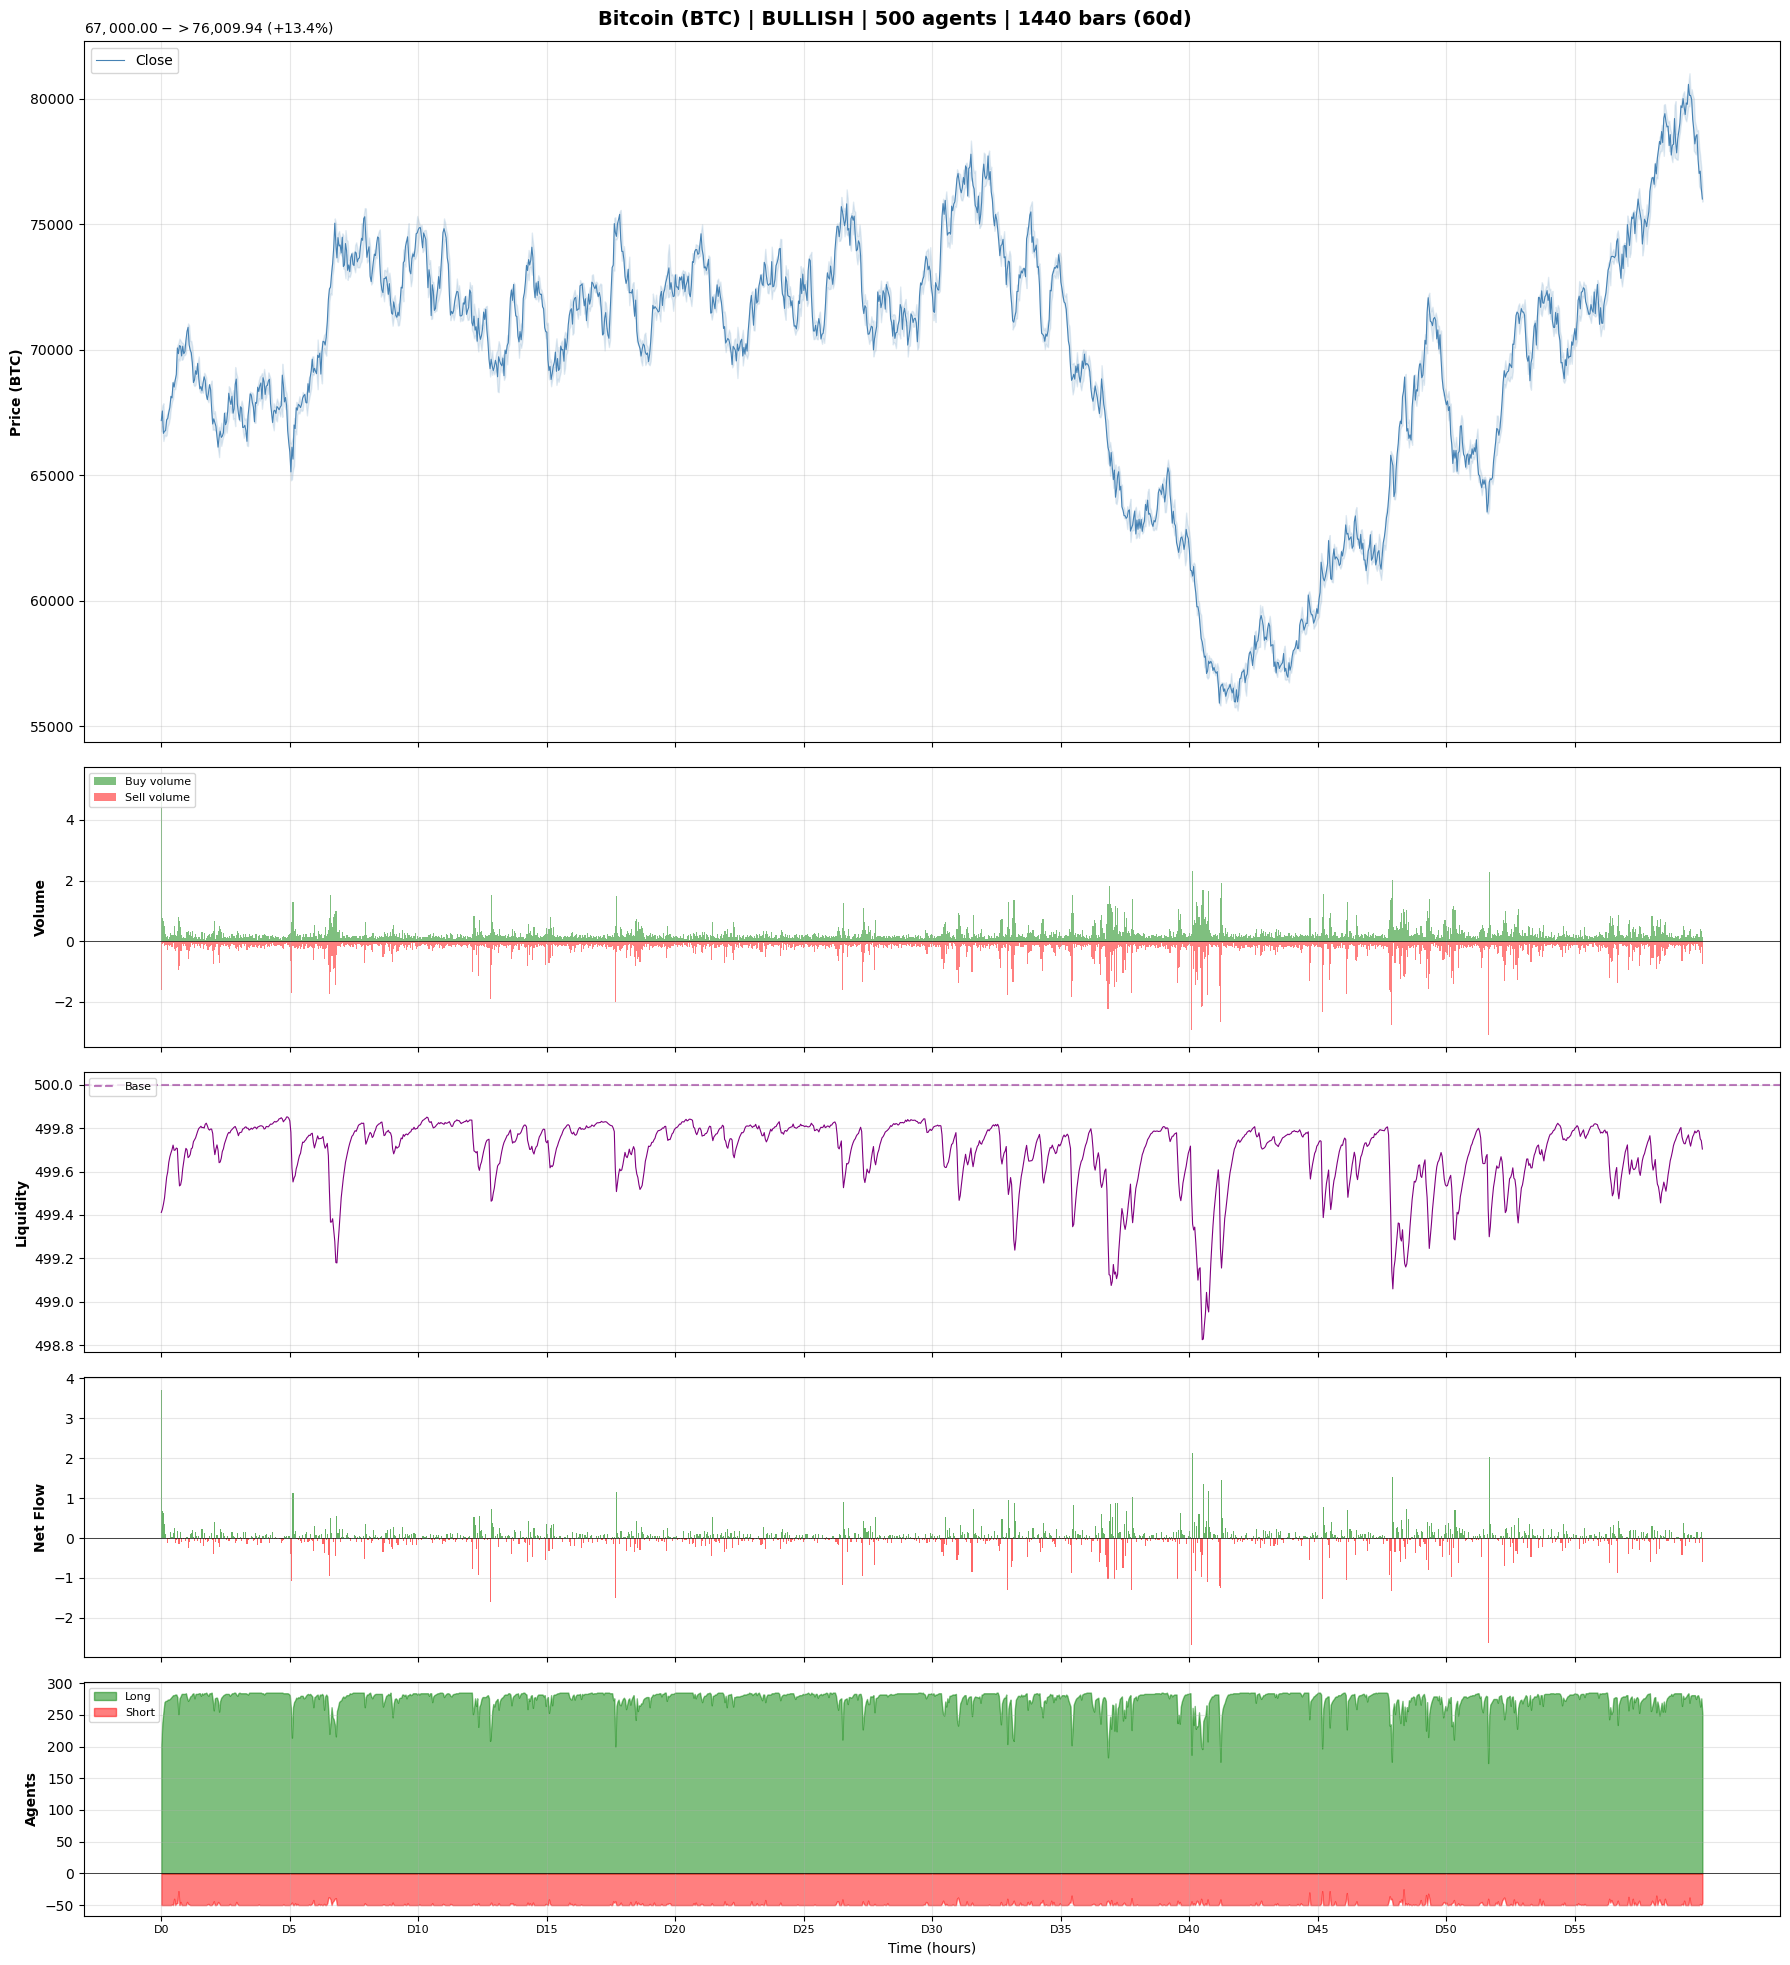

In [8]:
# -- Bitcoin Bullish --
result_btc_bull = run_simulation("BTC", MarketCondition.BULLISH, n_agents=500, seed=42)
print_summary(result_btc_bull)
plot_simulation(result_btc_bull)


 Bitcoin (BTC) | BEARISH
  Duration:       1440 bars (60 days)
  Agents:         500
  Total trades:   374,275

  Price:
    Start:        $   67,106.40
    End:          $   29,448.53
    Return:            -56.12%
    High:         $   69,784.14
    Low:          $   28,046.90
    Drawdown:          -59.81%

  Returns (hourly):
    Mean:            -0.05475%
    Std:              0.70243%
    Skew:              +0.023
    Kurtosis:          -0.096

  Volume:
    Mean/bar:              1.1
    Max bar:              10.2
    Total:               1,569

  Liquidity:
    Mean:                499.4
    Min:                 497.6

  Final positions:
    Long:             43 (9%)
    Short:           266 (53%)
    Flat:            191 (38%)

  Agent P&L:
    Mean:         $   +1,580.77
    Median:       $     +283.37
    Std:          $    4,306.45
    Winners:         285 (57%)
    Losers:           50 (10%)
    Best:         $  +52,917.65
    Worst:        $   -5,380.34


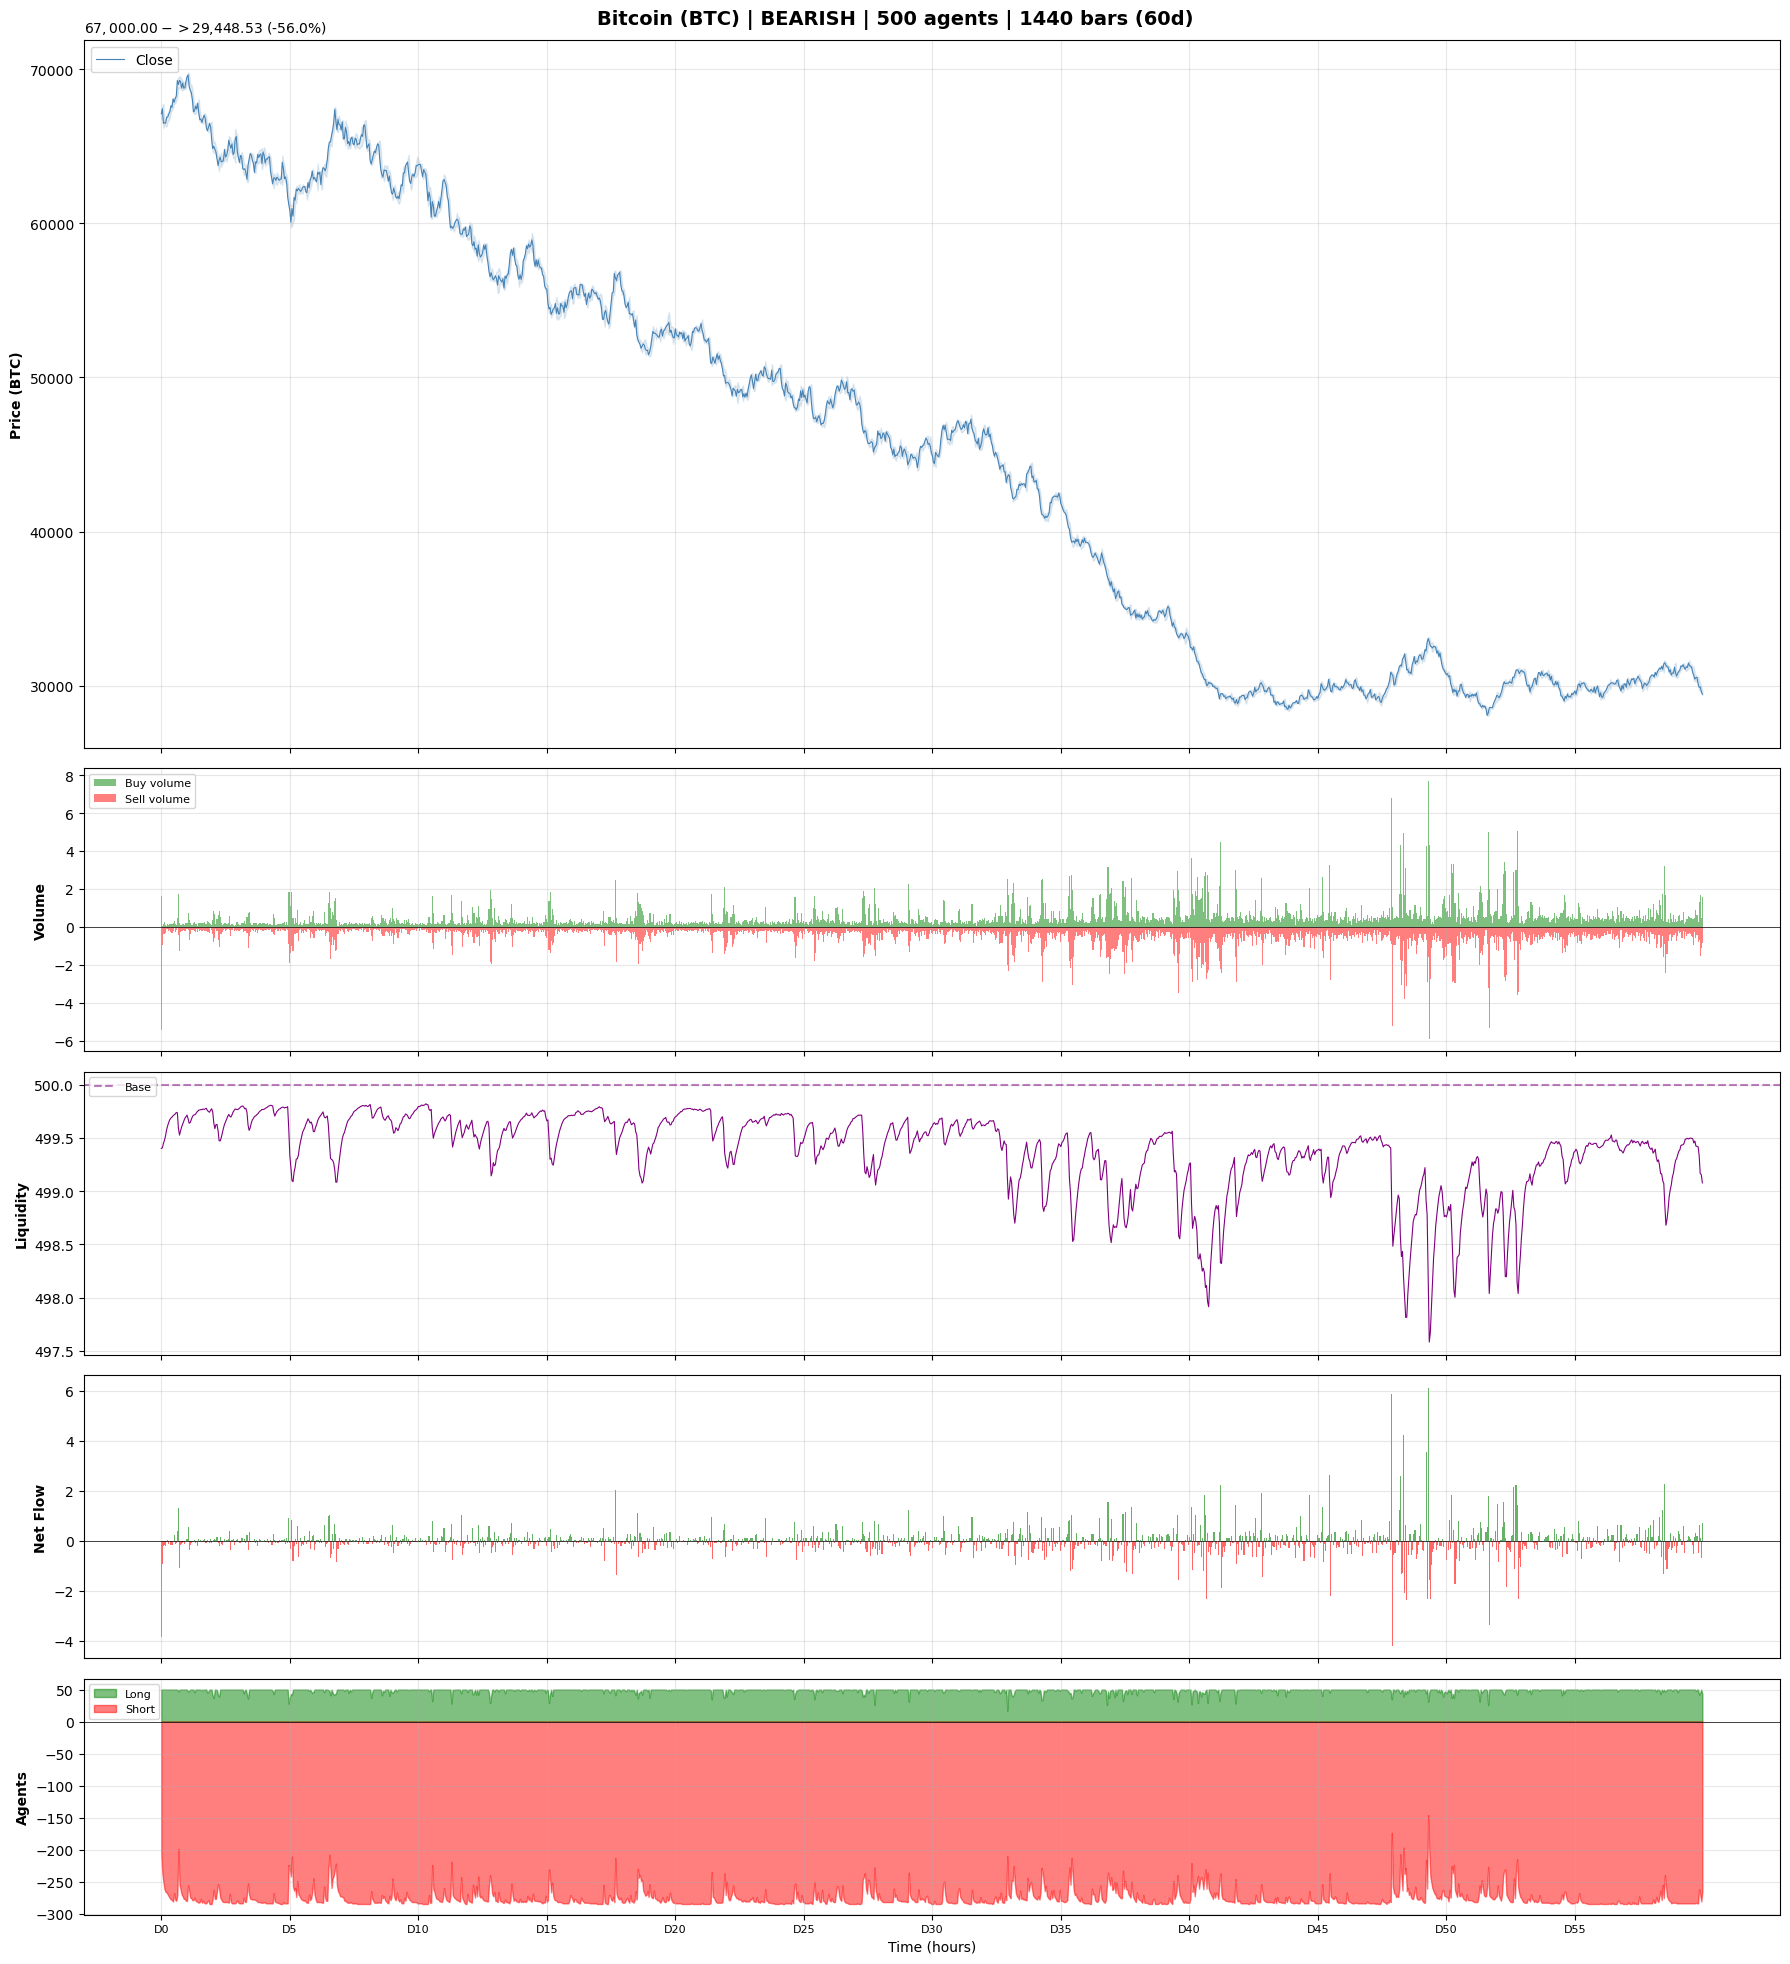

In [9]:
# -- Bitcoin Bearish --
result_btc_bear = run_simulation("BTC", MarketCondition.BEARISH, n_agents=500, seed=42)
print_summary(result_btc_bear)
plot_simulation(result_btc_bear)


 Gold (XAU) | BULLISH
  Duration:       1440 bars (60 days)
  Agents:         500
  Total trades:   372,544

  Price:
    Start:        $    2,351.91
    End:          $    2,478.47
    Return:             +5.38%
    High:         $    2,518.86
    Low:          $    2,273.01
    Drawdown:           -9.76%

  Returns (hourly):
    Mean:            +0.00381%
    Std:              0.18051%
    Skew:              +0.024
    Kurtosis:          -0.090

  Volume:
    Mean/bar:              8.8
    Max bar:             199.7
    Total:              12,646

  Liquidity:
    Mean:                797.4
    Min:                 785.0

  Final positions:
    Long:            285 (57%)
    Short:            50 (10%)
    Flat:            165 (33%)

  Agent P&L:
    Mean:         $     +517.25
    Median:       $      +27.48
    Std:          $    1,622.90
    Winners:         282 (56%)
    Losers:           53 (11%)
    Best:         $  +15,338.19
    Worst:        $   -1,616.86


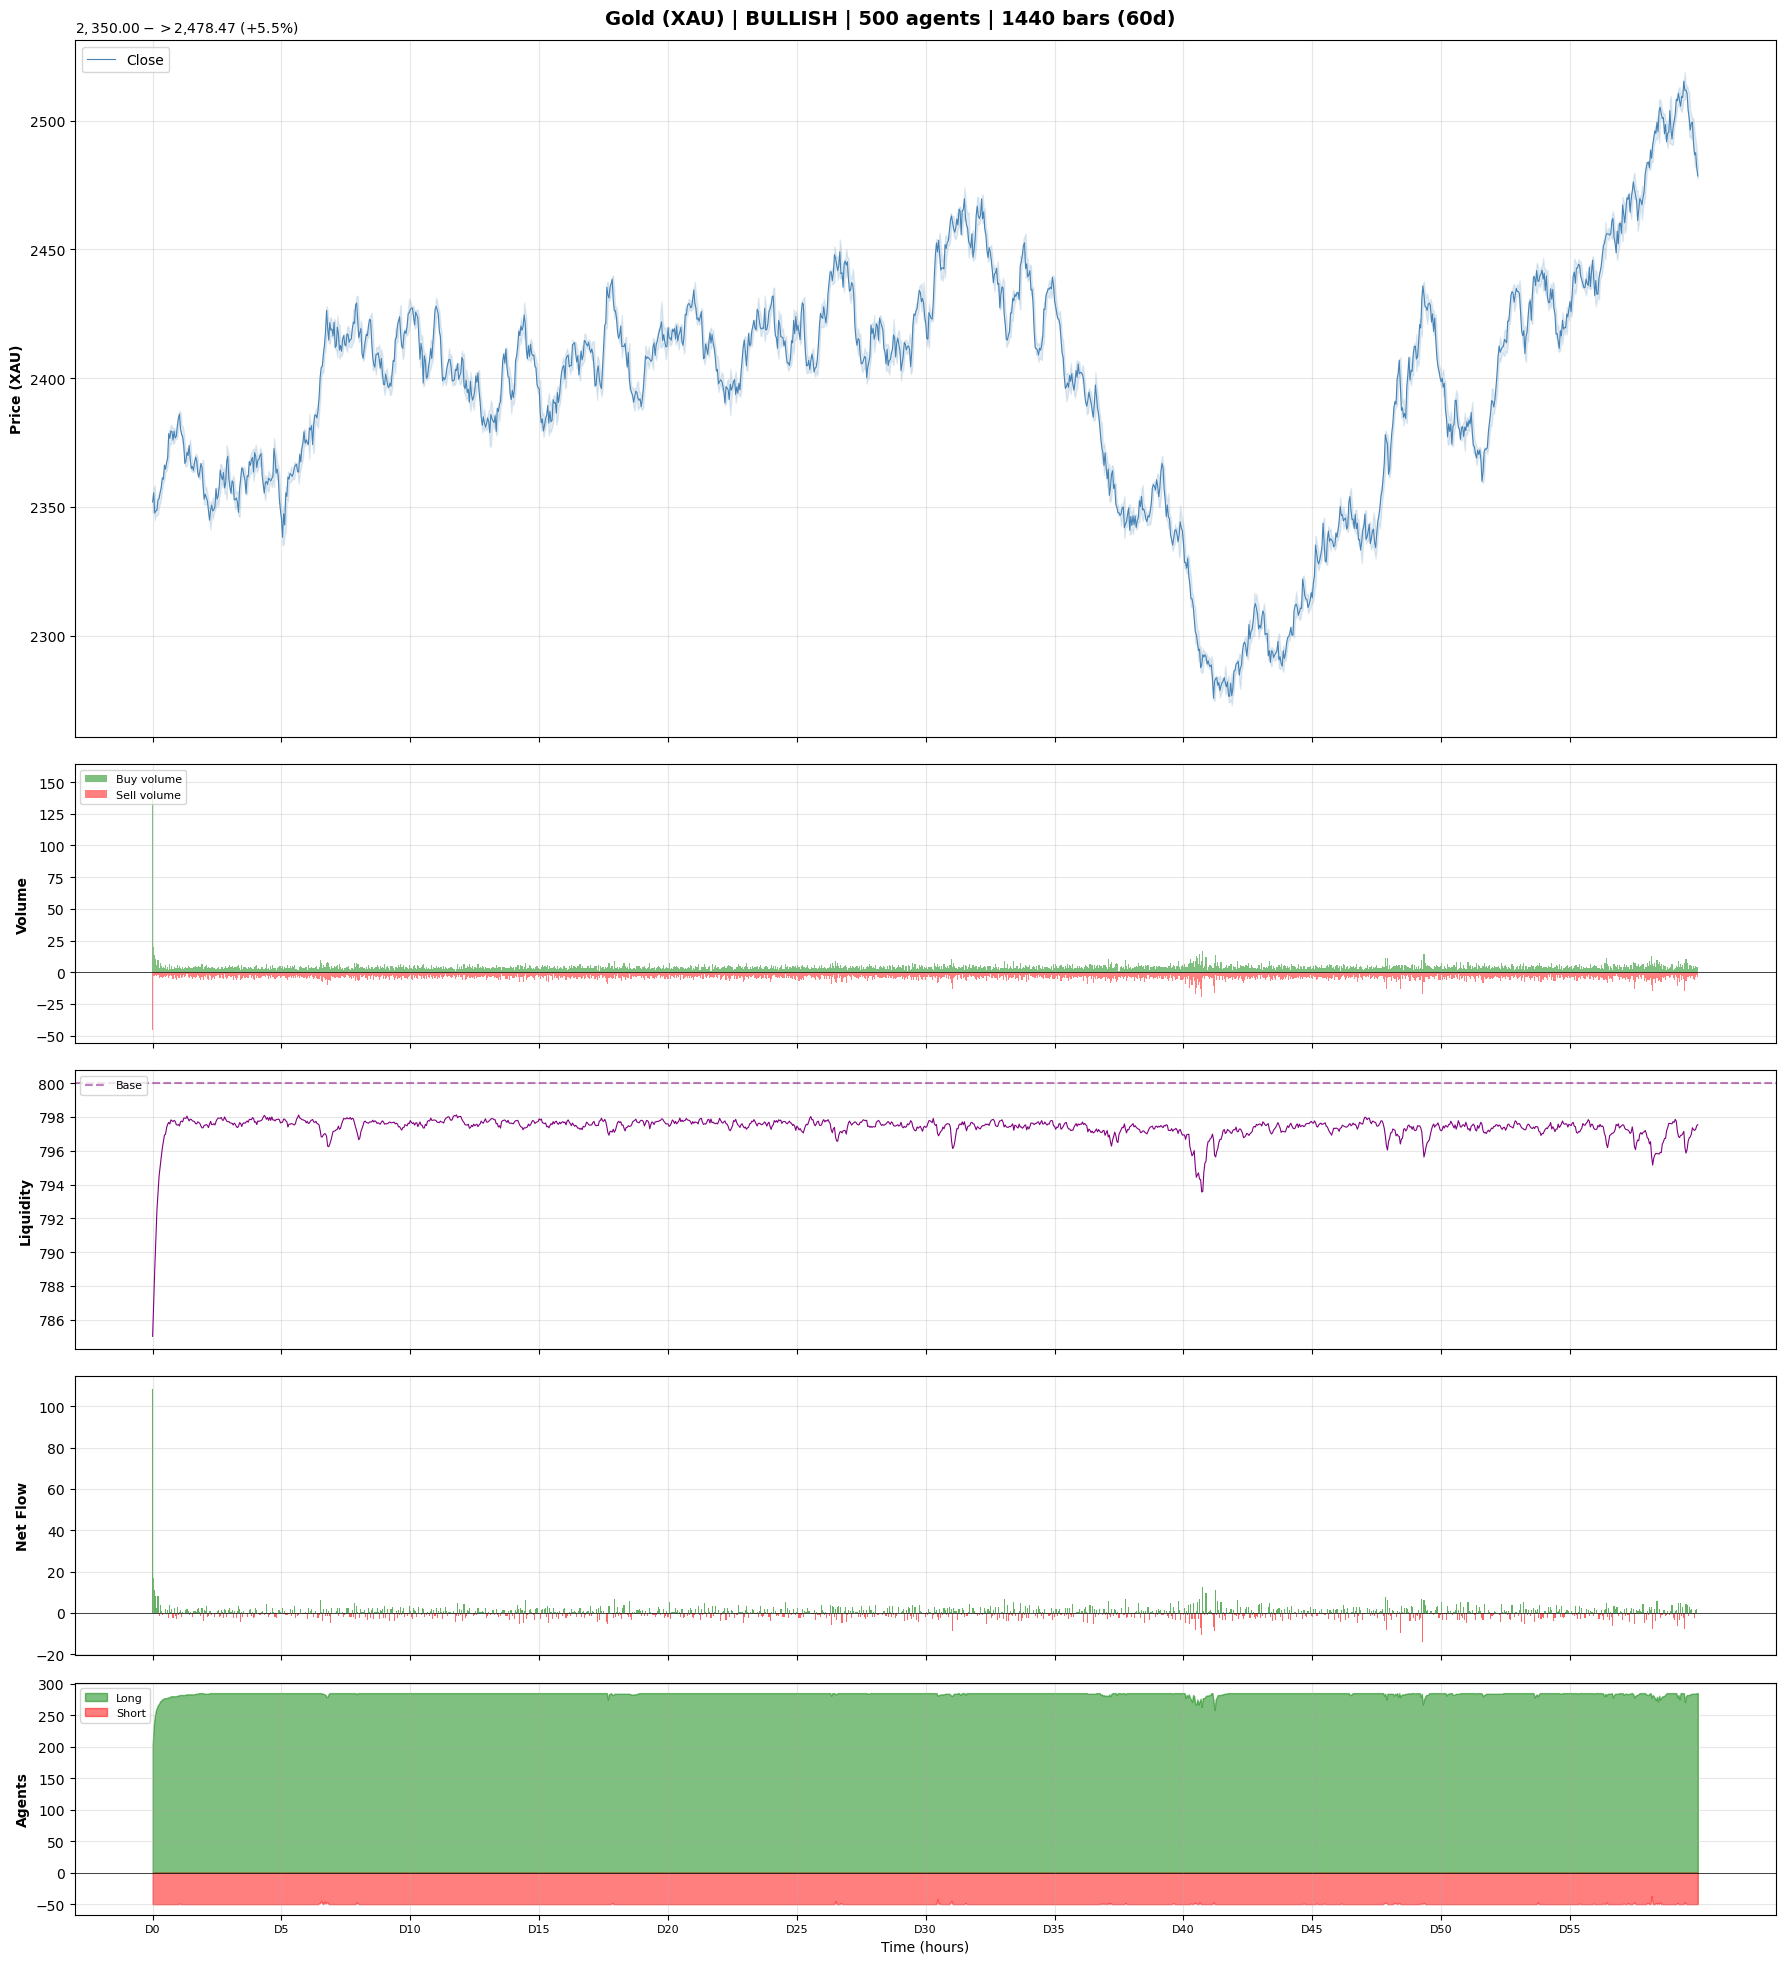

In [10]:
# -- Gold Bullish --
result_xau_bull = run_simulation("XAU", MarketCondition.BULLISH, n_agents=500, seed=42)
print_summary(result_xau_bull)
plot_simulation(result_xau_bull)


 Gold (XAU) | NEUTRAL
  Duration:       1440 bars (60 days)
  Agents:         500
  Total trades:   21,759

  Price:
    Start:        $    2,351.37
    End:          $    2,175.93
    Return:             -7.46%
    High:         $    2,391.10
    Low:          $    2,075.78
    Drawdown:          -13.19%

  Returns (hourly):
    Mean:            -0.00523%
    Std:              0.18062%
    Skew:              +0.027
    Kurtosis:          -0.093

  Volume:
    Mean/bar:              7.1
    Max bar:              18.3
    Total:              10,222

  Liquidity:
    Mean:                797.9
    Min:                 796.7

  Final positions:
    Long:             25 (5%)
    Short:            25 (5%)
    Flat:            450 (90%)

  Agent P&L:
    Mean:         $       -3.55
    Median:       $       +0.00
    Std:          $       38.24
    Winners:          12 (2%)
    Losers:           38 (8%)
    Best:         $     +361.86
    Worst:        $     -453.03


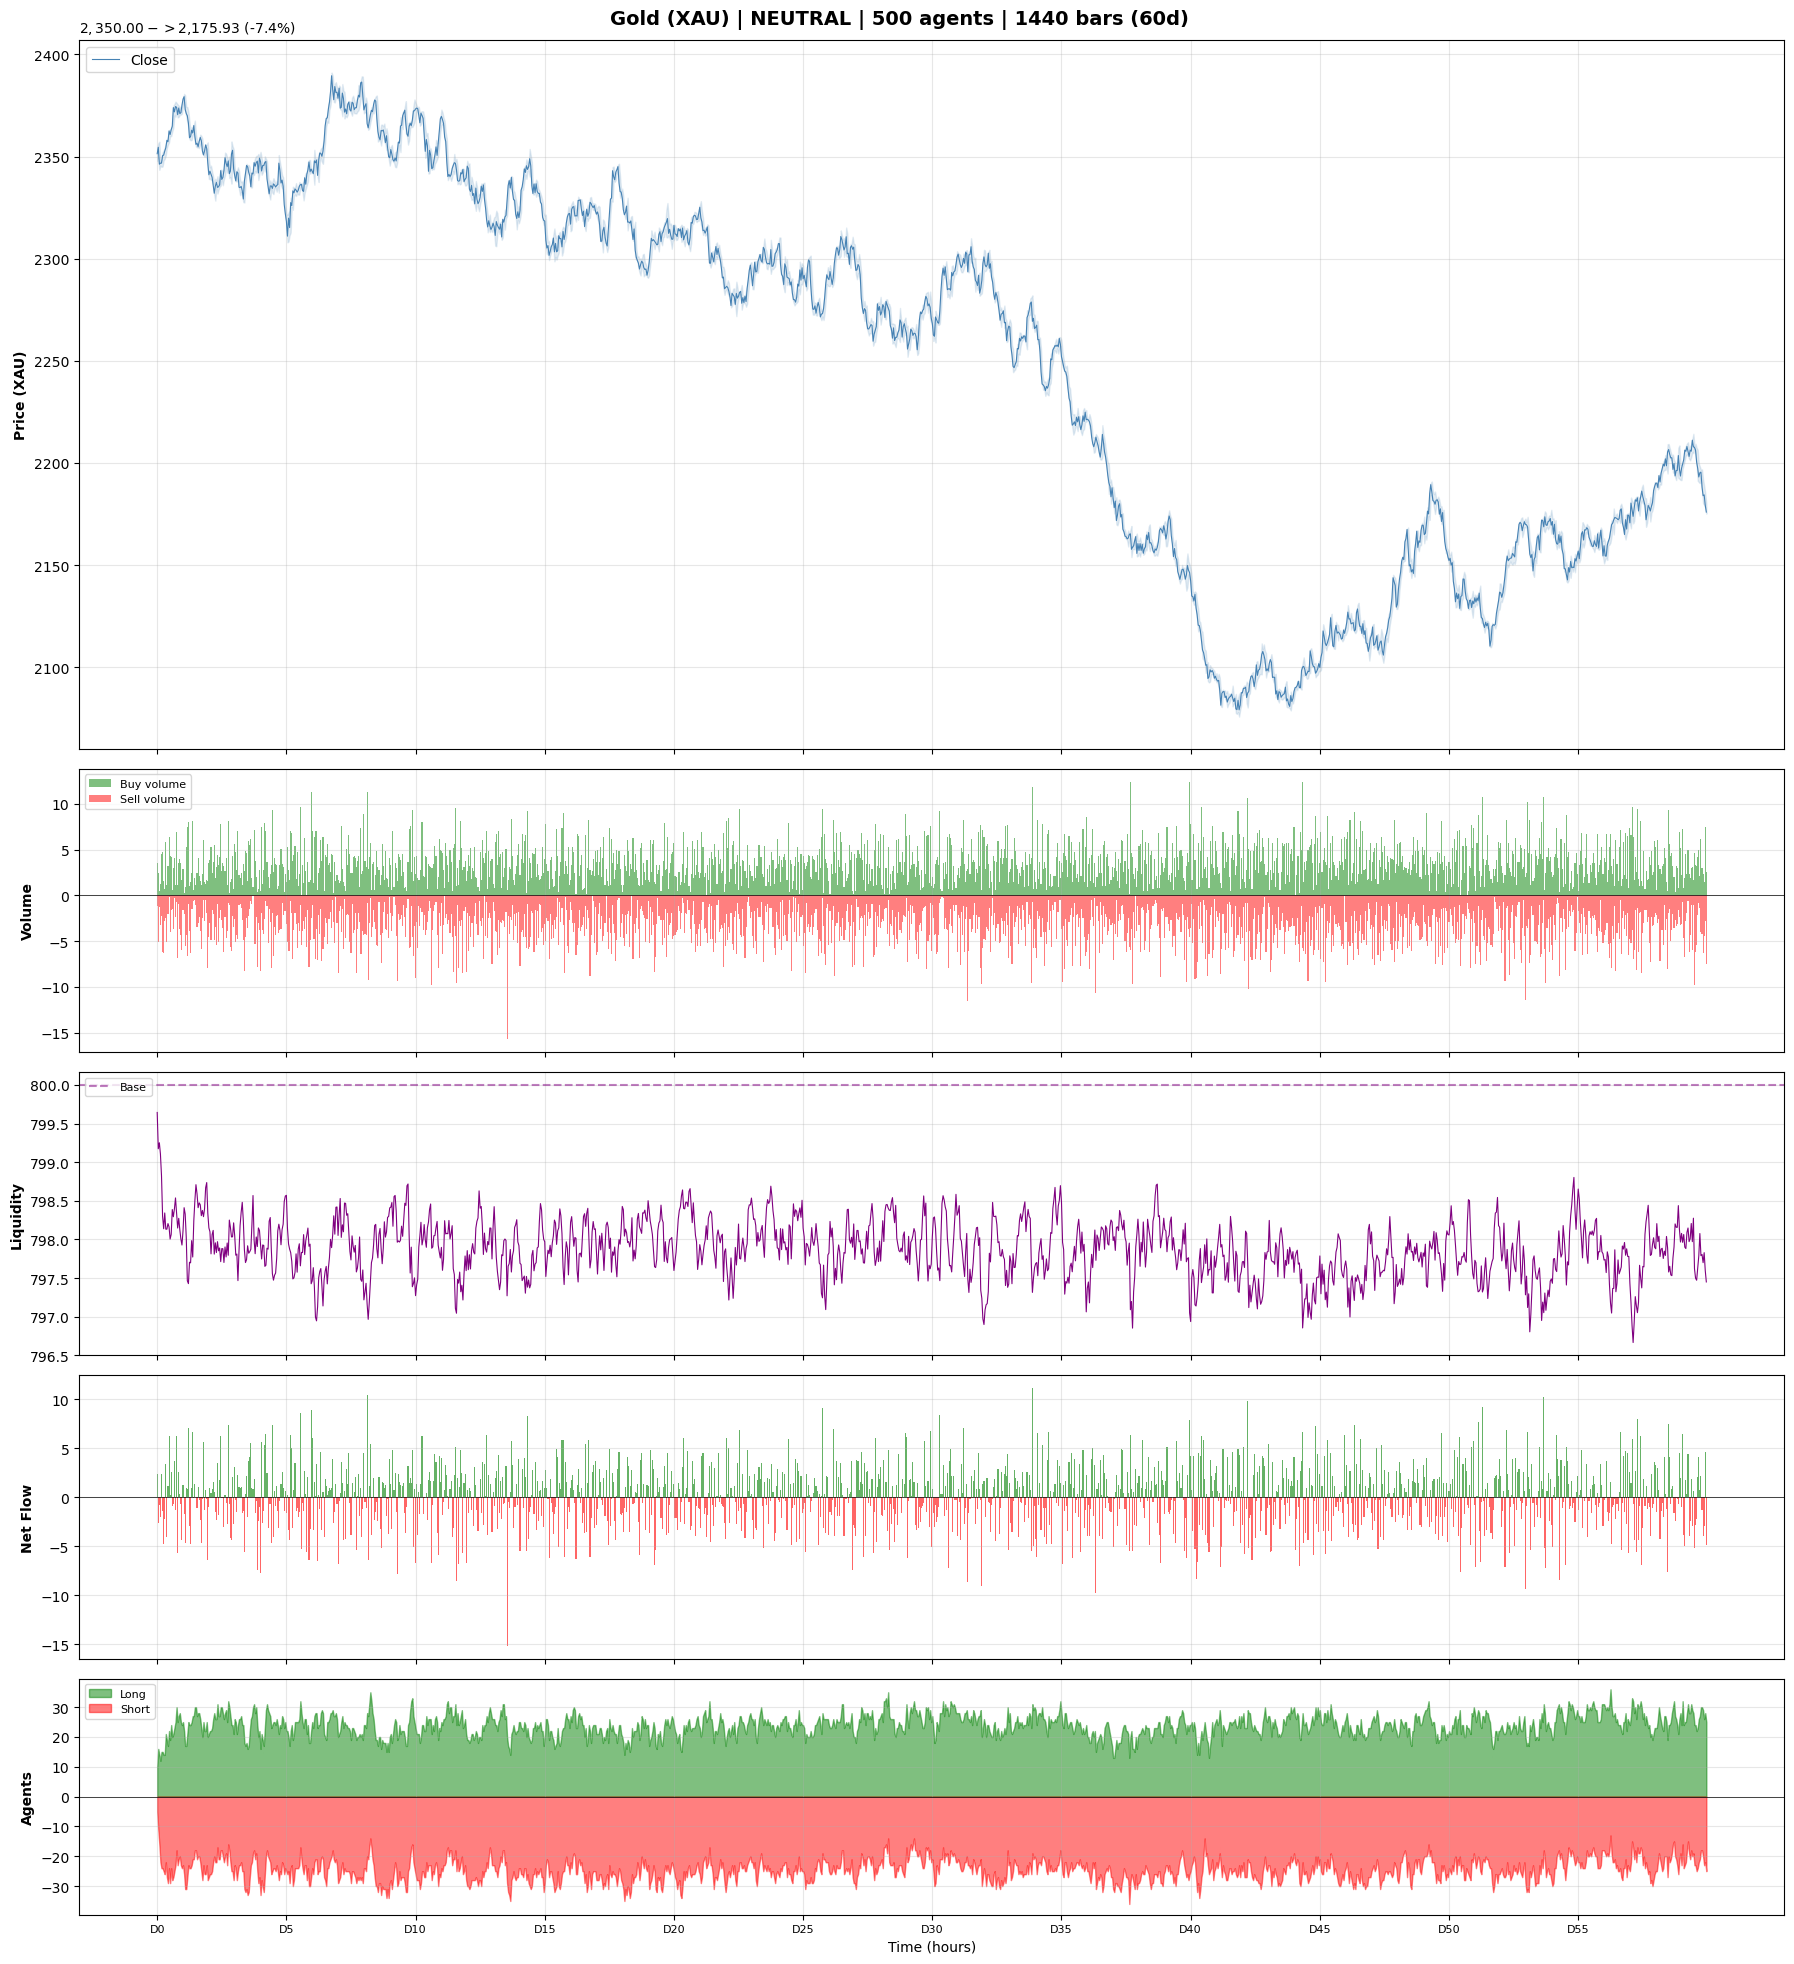

In [11]:
# -- Gold Neutral --
result_xau_neut = run_simulation("XAU", MarketCondition.NEUTRAL, n_agents=500, seed=42)
print_summary(result_xau_neut)
plot_simulation(result_xau_neut)


 Meta Platforms (META) | BEARISH
  Duration:       1440 bars (60 days)
  Agents:         500
  Total trades:   373,737

  Price:
    Start:        $      499.80
    End:          $      269.53
    Return:            -46.07%
    High:         $      512.13
    Low:          $      261.05
    Drawdown:          -49.03%

  Returns (hourly):
    Mean:            -0.04164%
    Std:              0.50272%
    Skew:              +0.020
    Kurtosis:          -0.118

  Volume:
    Mean/bar:            102.6
    Max bar:           1,004.1
    Total:             147,762

  Liquidity:
    Mean:                559.1
    Min:                 448.8

  Final positions:
    Long:             47 (9%)
    Short:           277 (55%)
    Flat:            176 (35%)

  Agent P&L:
    Mean:         $   +1,429.95
    Median:       $     +218.65
    Std:          $    3,832.43
    Winners:         285 (57%)
    Losers:           50 (10%)
    Best:         $  +36,654.42
    Worst:        $   -4,221.57


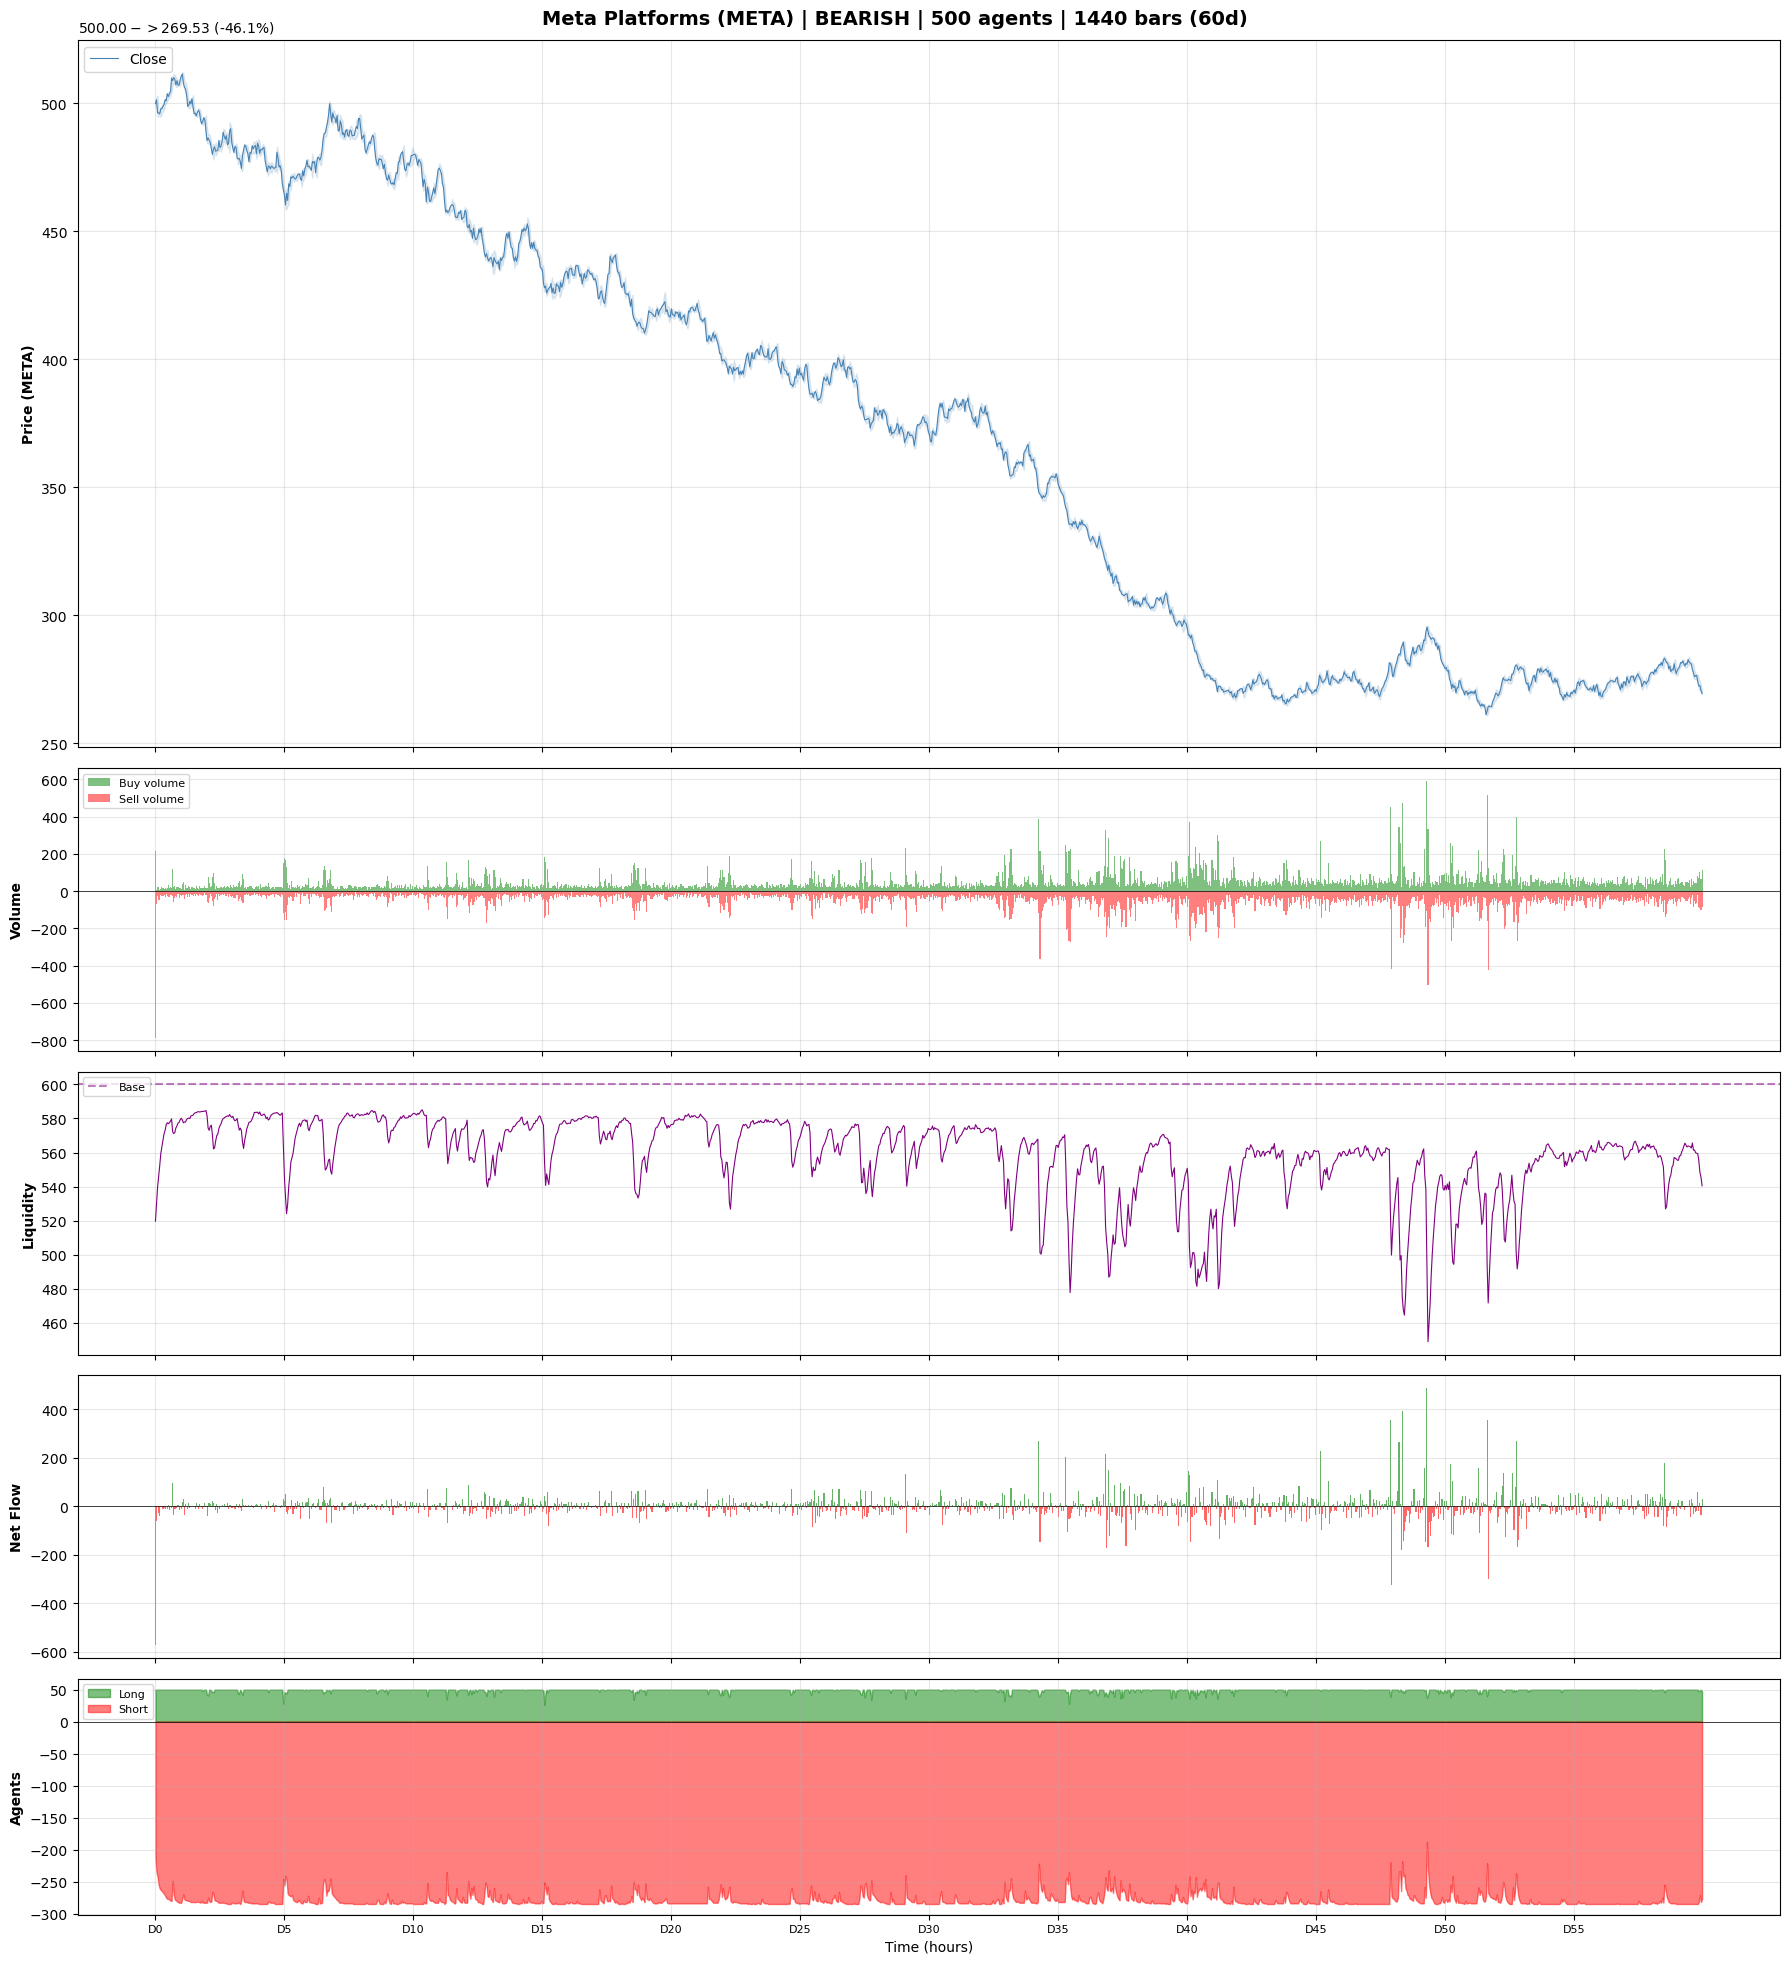

In [12]:
# -- META Bearish --
result_meta_bear = run_simulation("META", MarketCondition.BEARISH, n_agents=500, seed=42)
print_summary(result_meta_bear)
plot_simulation(result_meta_bear)


 Crude Oil (CL) | BULLISH
  Duration:       1440 bars (60 days)
  Agents:         500
  Total trades:   372,831

  Price:
    Start:        $       78.24
    End:          $       88.16
    Return:            +12.68%
    High:         $       90.52
    Low:          $       75.52
    Drawdown:          -16.57%

  Returns (hourly):
    Mean:            +0.00875%
    Std:              0.30213%
    Skew:              +0.025
    Kurtosis:          -0.077

  Volume:
    Mean/bar:            300.0
    Max bar:           6,041.9
    Total:             432,066

  Liquidity:
    Mean:                580.3
    Min:                 216.7

  Final positions:
    Long:            284 (57%)
    Short:            50 (10%)
    Flat:            166 (33%)

  Agent P&L:
    Mean:         $     +782.71
    Median:       $      +57.86
    Std:          $    2,579.81
    Winners:         282 (56%)
    Losers:           53 (11%)
    Best:         $  +30,106.29
    Worst:        $     -933.90


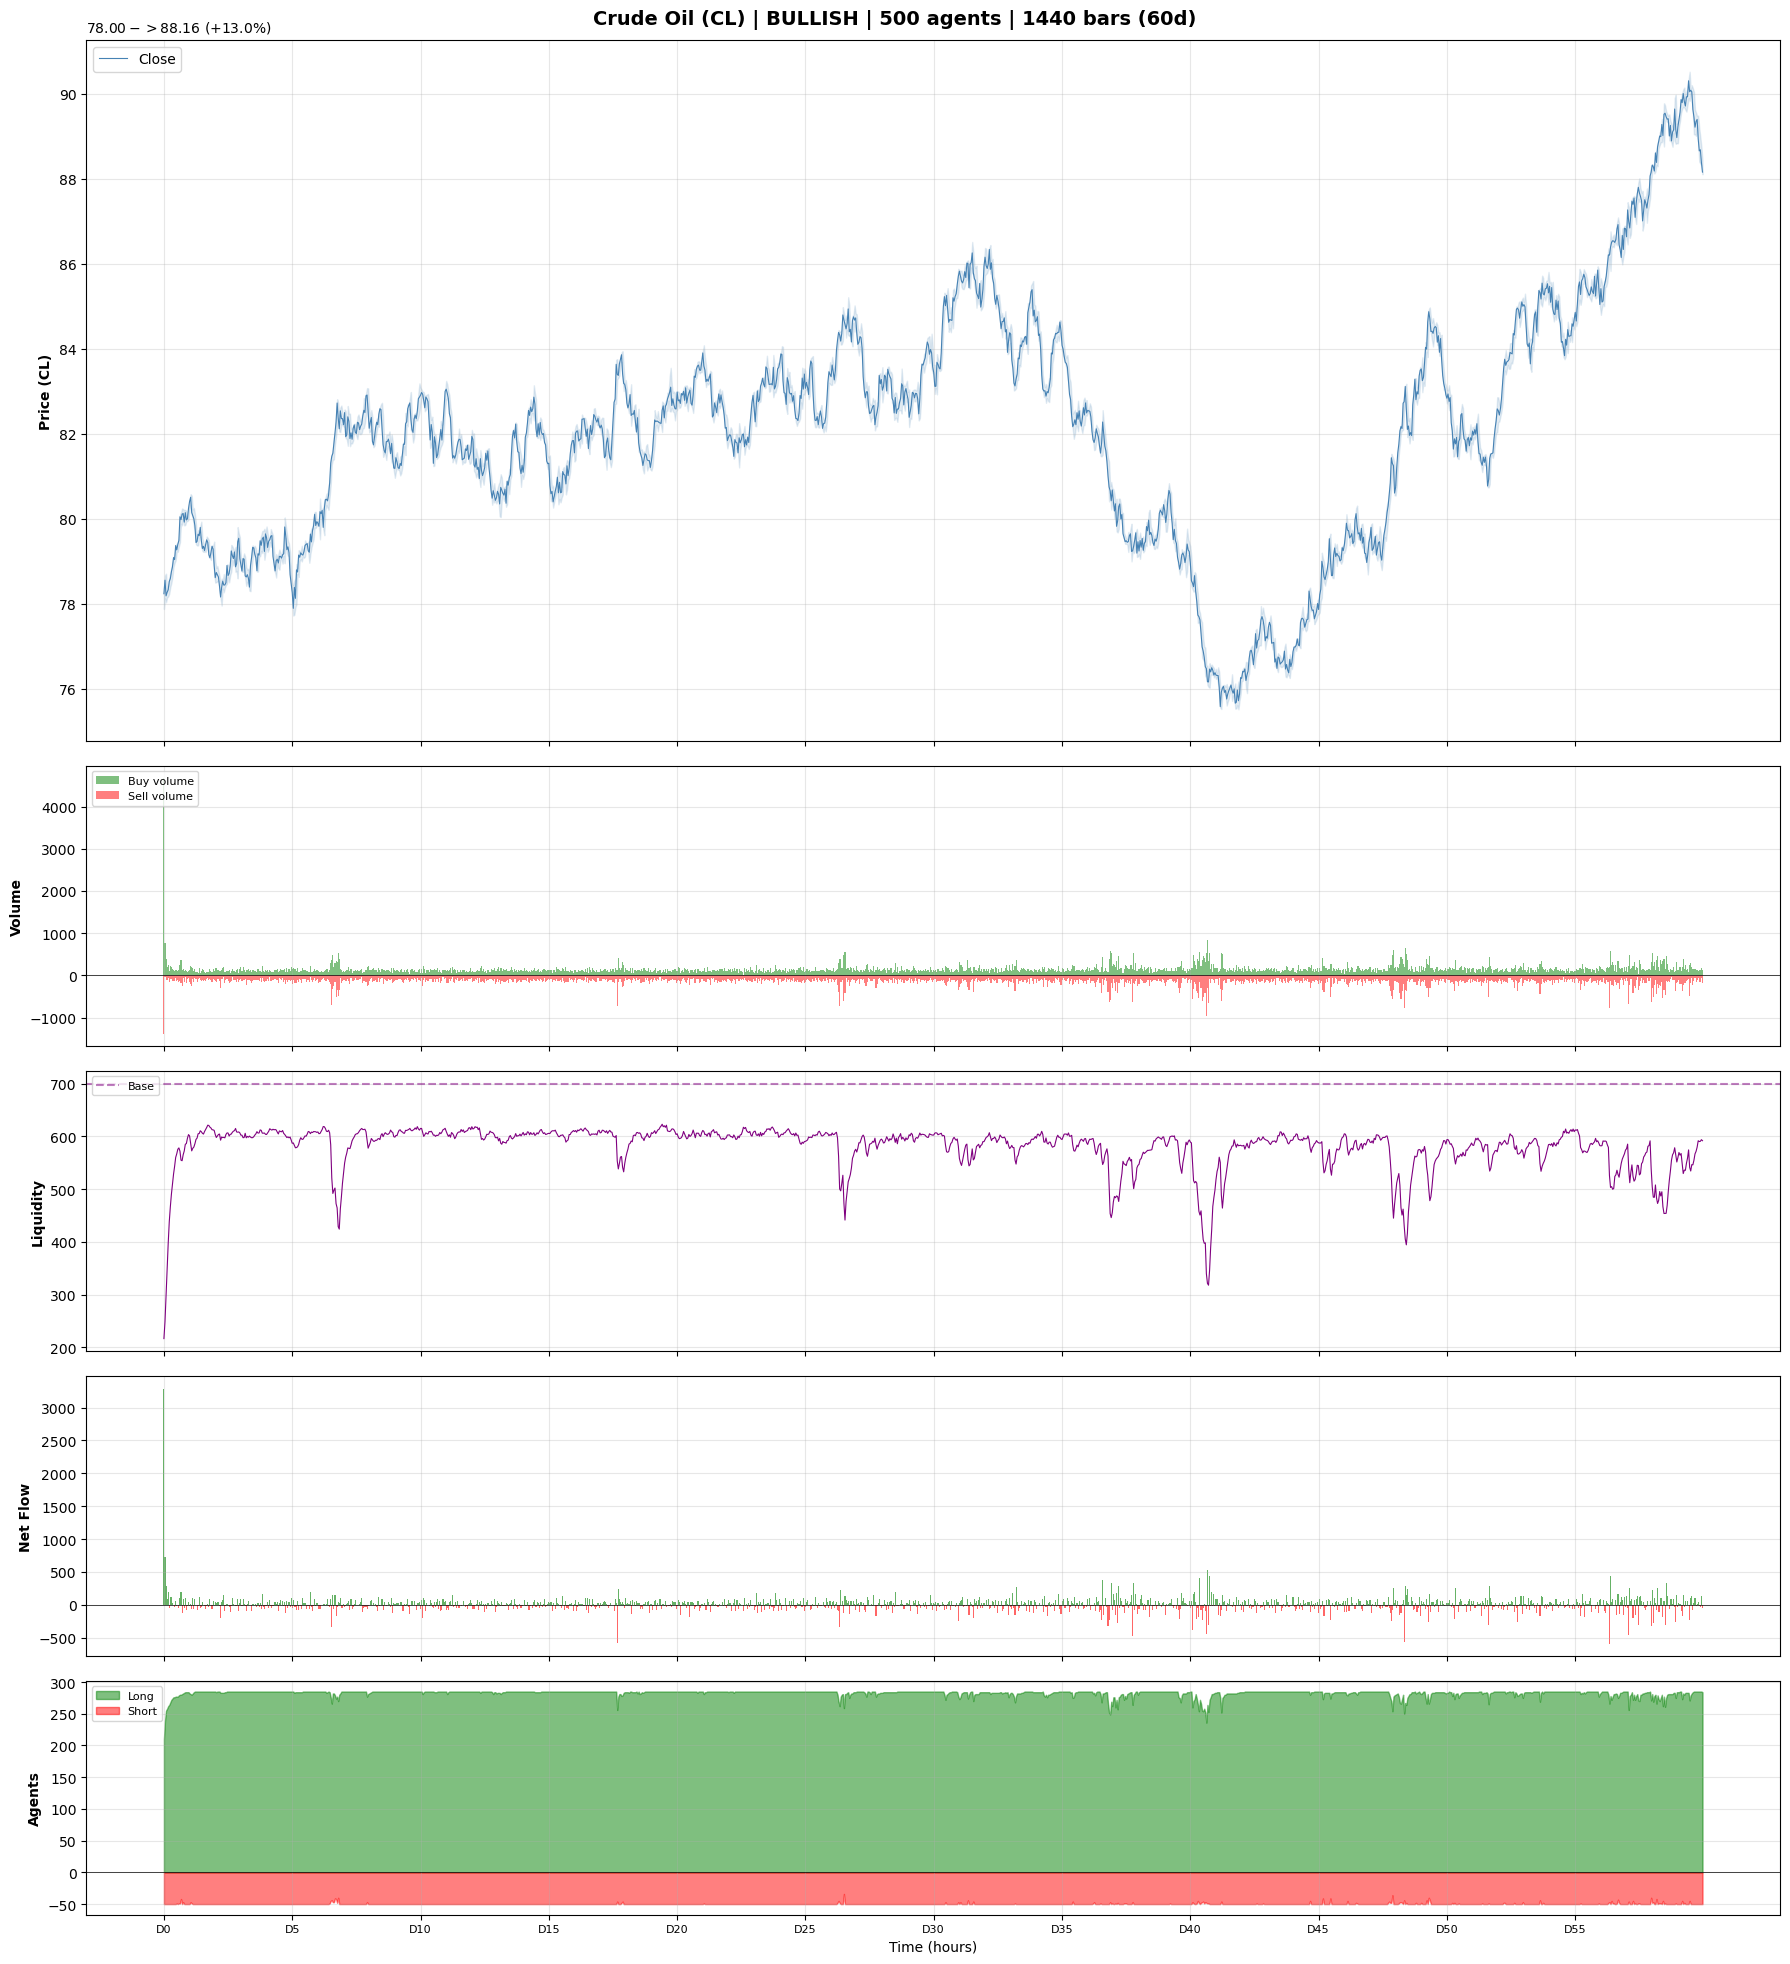

In [13]:
# -- Crude Oil Bullish --
result_cl_bull = run_simulation("CL", MarketCondition.BULLISH, n_agents=500, seed=42)
print_summary(result_cl_bull)
plot_simulation(result_cl_bull)

## 7. Compare All Assets Under Same Condition

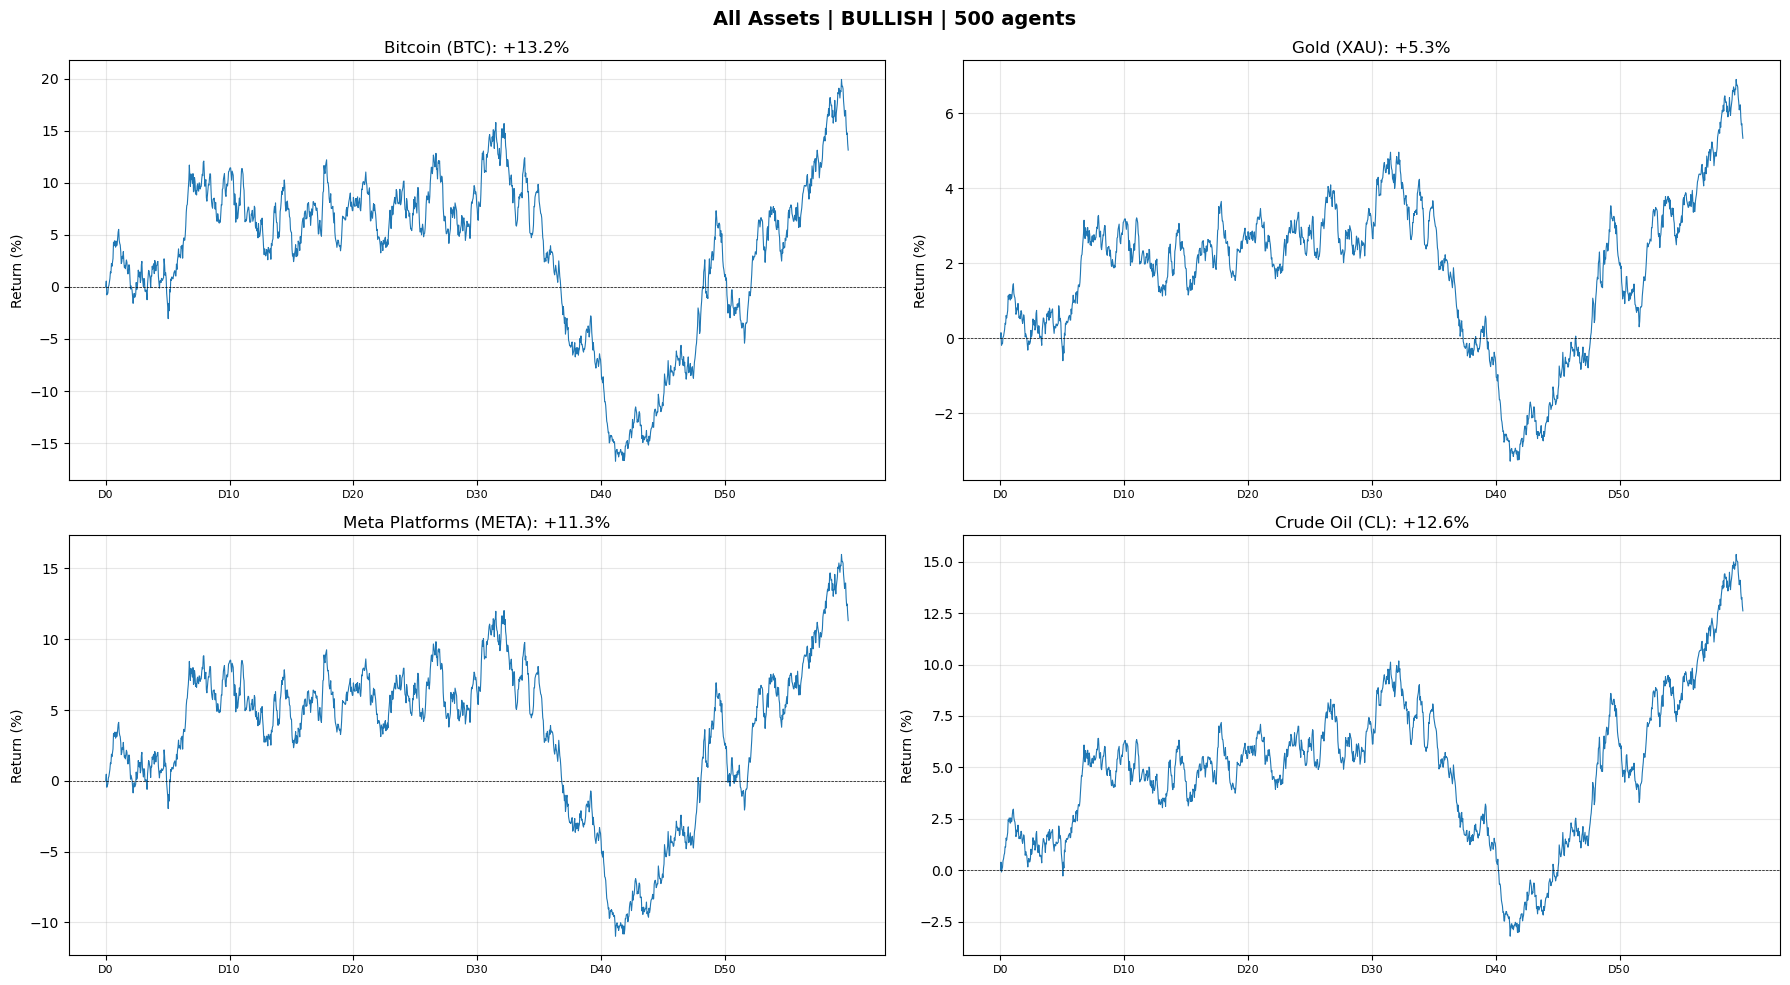

In [14]:
def compare_assets(condition: MarketCondition, n_agents: int = 500, seed: int = 42):
    results = {}
    for key in ASSETS:
        results[key] = run_simulation(key, condition, n_agents=n_agents, seed=seed)

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    fig.suptitle(f"All Assets | {condition.value.upper()} | {n_agents} agents", fontsize=14, fontweight='bold')

    for ax, (key, res) in zip(axes.flat, results.items()):
        # Normalize to percent return
        norm_prices = (res.closes / res.closes[0] - 1) * 100
        ax.plot(norm_prices, linewidth=0.8)
        ax.set_title(f"{res.asset.name} ({res.asset.symbol}): {norm_prices[-1]:+.1f}%")
        ax.set_ylabel('Return (%)')
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

        day_ticks = np.arange(0, res.n_bars, 24 * 10)
        day_labels = [f"D{i // 24}" for i in day_ticks]
        ax.set_xticks(day_ticks)
        ax.set_xticklabels(day_labels, fontsize=8)

    plt.tight_layout()
    plt.show()

    return results


# Compare all assets in a bullish market
bull_results = compare_assets(MarketCondition.BULLISH)

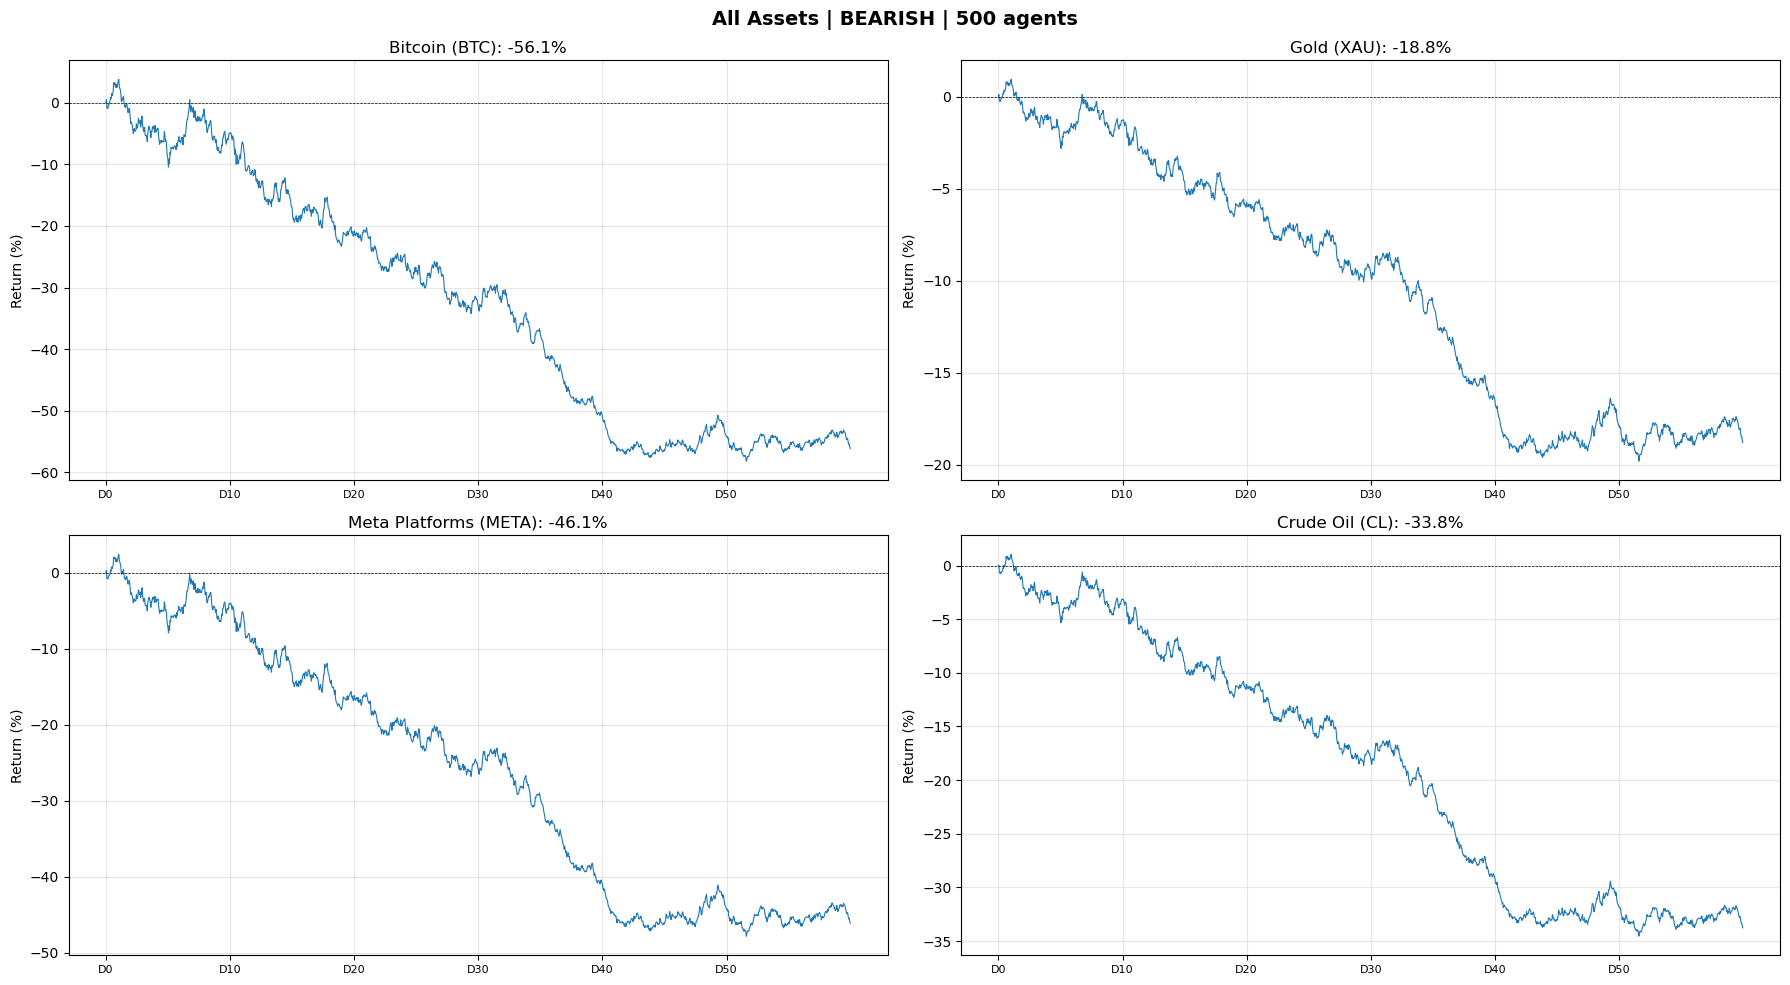

In [15]:
# Compare all assets in a bearish market
bear_results = compare_assets(MarketCondition.BEARISH)

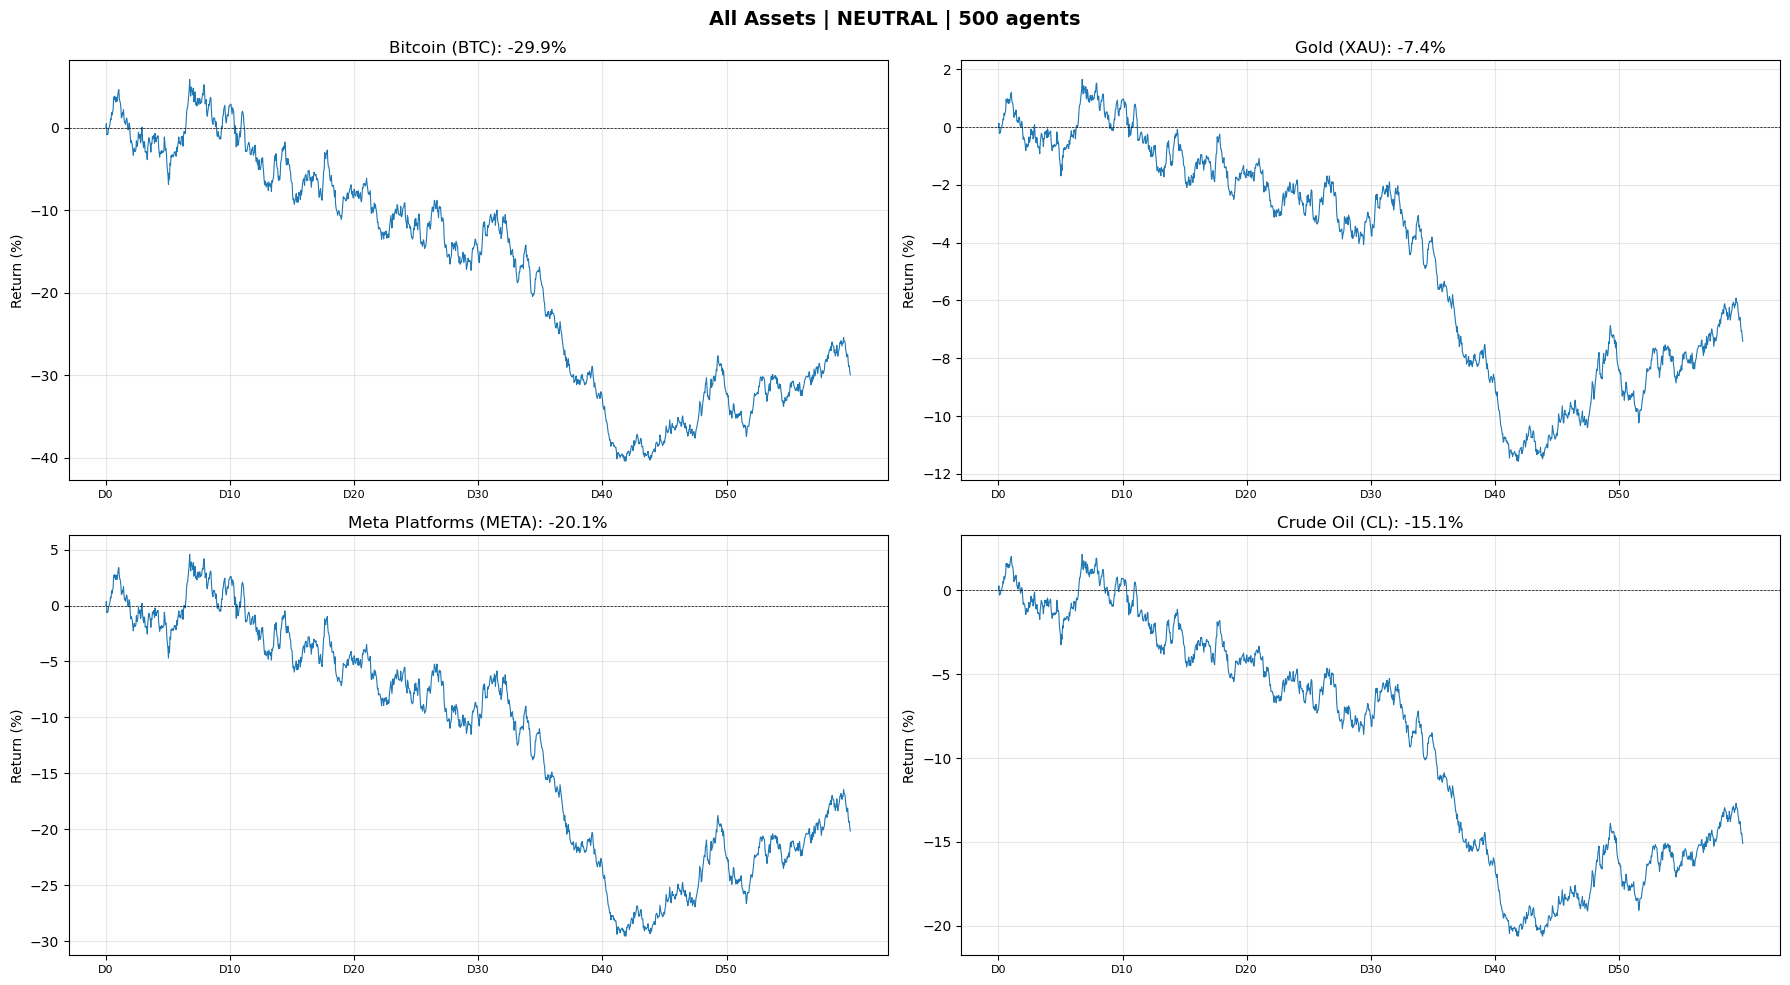

In [16]:
# Compare all assets in a neutral market
neutral_results = compare_assets(MarketCondition.NEUTRAL)

## 8. Agent P&L by Bias Type

In [ ]:
def analyze_pnl_by_bias(result: SimulationResult):
    bias_pnls = {}
    for agent in result.agents:
        total_pnl = result.get_agent_pnl(agent)
        bias_name = agent.bias.value
        if bias_name not in bias_pnls:
            bias_pnls[bias_name] = []
        bias_pnls[bias_name].append(total_pnl)

    print(f"\nAgent P&L by Bias | {result.asset.symbol} {result.condition.value.upper()}")
    print(f"{'Bias':<18} {'Count':>6} {'Mean P&L':>12} {'Median':>12} {'Win %':>8} {'Best':>12} {'Worst':>12}")
    print("-" * 82)

    for bias_name, pnls in sorted(bias_pnls.items()):
        arr = np.array(pnls)
        win_pct = np.sum(arr > 0) / len(arr) * 100
        print(f"{bias_name:<18} {len(arr):>6} ${np.mean(arr):>+10,.2f} ${np.median(arr):>+10,.2f} {win_pct:>6.0f}% ${np.max(arr):>+10,.2f} ${np.min(arr):>+10,.2f}")

    # Box plot
    fig, ax = plt.subplots(figsize=(12, 5))
    labels = sorted(bias_pnls.keys())
    data = [bias_pnls[l] for l in labels]
    bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=True,
                    flierprops=dict(marker='.', markersize=3, alpha=0.3))

    # Colors mapped alphabetically: contrarian, mean_reverter, momentum, passive, trend_follower
    colors = ['#F44336', '#2196F3', '#FF9800', '#9E9E9E', '#4CAF50']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)

    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_ylabel('Total P&L ($)')
    ax.set_title(f"P&L Distribution by Agent Bias | {result.asset.symbol} {result.condition.value.upper()}")
    plt.tight_layout()
    plt.show()


# Analyze the BTC bullish run
analyze_pnl_by_bias(result_btc_bull)


Agent P&L by Bias | BTC BEARISH
Bias                Count     Mean P&L       Median    Win %         Best        Worst
----------------------------------------------------------------------------------
contrarian             50 $ -1,516.64 $ -1,229.37      0% $   -188.61 $ -5,380.34
mean_reverter          75 $    +88.08 $     +0.00     13% $ +1,814.89 $     +0.00
momentum              100 $     +0.00 $     +0.00      0% $     +0.00 $     +0.00
noise                 125 $ +4,565.93 $ +2,062.60    100% $+52,917.65 $    +77.41
trend_follower        150 $ +1,925.80 $ +1,378.48    100% $+14,869.53 $    +41.82


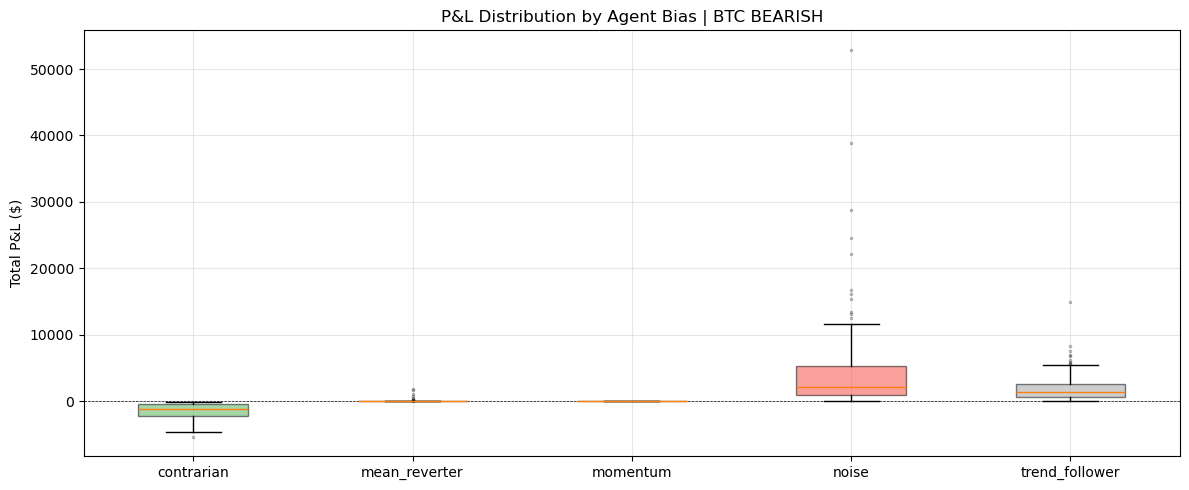

In [18]:
# Analyze BTC bearish -- who profits in a downturn?
analyze_pnl_by_bias(result_btc_bear)

## 9. Sensitivity: Agent Count

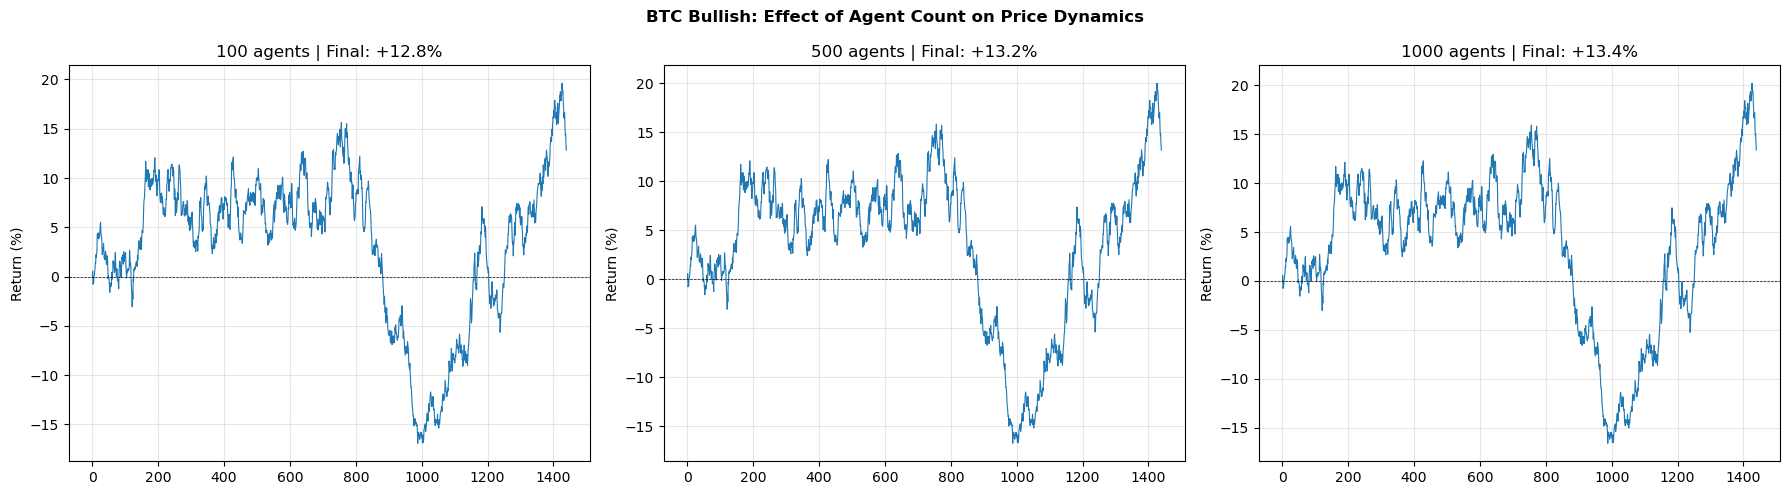

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, n in enumerate([100, 500, 1000]):
    res = run_simulation("BTC", MarketCondition.BULLISH, n_agents=n, seed=42)
    norm = (res.closes / res.closes[0] - 1) * 100
    axes[i].plot(norm, linewidth=0.8)
    axes[i].set_title(f"{n} agents | Final: {norm[-1]:+.1f}%")
    axes[i].set_ylabel('Return (%)')
    axes[i].axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.suptitle('BTC Bullish: Effect of Agent Count on Price Dynamics', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Scratchpad

In [ ]:
# Use this cell to run custom experiments.
# Example: high volatility BTC with 1000 agents in neutral market

# You can modify asset configs on the fly:
# ASSETS["BTC"].hourly_volatility = 0.012  # crank up volatility
# ASSETS["BTC"].base_liquidity = 300.0      # thin the book

# result = run_simulation("BTC", MarketCondition.NEUTRAL, n_agents=1000, seed=99)
# print_summary(result)
# plot_simulation(result)